# Instituto Tecnológico y de Estudios Superiores de Monterrey

## Maestría en Inteligencia Artificial Aplicada

### Proyecto Integrador (TC5035.10)

# Algoritmos de regresión de Machine Learning para la estimación del carbono en bosques mezclados de Durango

## Avance 5. Modelo final

**Dra. María Valentina Narváez Terán**

**Gerónimo Quiñónez Barraza – A01795904**  
**Alfredo Rigoberto Álvarez Suárez – A01796142**  
**Humberto Alonso Torres Hernández – A01793682**

**Durango, Dgo. 07 de junio de 2026**

#**1. Importación de librerías**
Las librerías utilizadas permiten realizar el preprocesamiento, entrenamiento, optimización y evaluación de modelos de aprendizaje automático para la estimación de CO₂eA. Se incluyen herramientas para manipulación de datos, partición de conjuntos de entrenamiento, validación y prueba, imputación de valores faltantes, normalización de variables, búsqueda de hiperparámetros y evaluación mediante R², RMSE y MAE. Además, se consideran diversas familias de algoritmos de regresión, incluyendo modelos lineales, vecinos cercanos, máquinas de soporte vectorial, árboles de decisión, métodos kernel, redes neuronales, procesos gaussianos, boosting y bagging, así como técnicas avanzadas de ensamble como Voting y Stacking, con el propósito de identificar las alternativas con mayor capacidad predictiva y de generalización


In [5]:
#@title Importación de librerías
# Librerías
#!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import Ridge, LinearRegression, Lasso, ElasticNet, BayesianRidge, HuberRegressor, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# **2. Carga de datos**
En esta sección se monta Google Drive en el entorno de Google Colab con el propósito de acceder a los archivos de entrada, resultados y recursos utilizados durante el desarrollo del proyecto. Esta conexión permite leer y almacenar información directamente desde el espacio de trabajo compartido del equipo, garantizando la disponibilidad y persistencia de los datos a lo largo de la ejecución del notebook.

En esta sección se carga el conjunto de datos utilizado para el desarrollo de los modelos predictivos. El archivo se encuentra almacenado en Google Drive y contiene las variables espectrales, topográficas, edáficas, de biodiversidad y de rodal empleadas para estimar el carbono equivalente aéreo (CO₂eA). Posteriormente, se visualizan los primeros registros de la base de datos con el fin de verificar la correcta lectura de la información y familiarizarse con la estructura de las variables disponibles para el análisis.

In [6]:
#@title Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#@title Cargar de datos
path = "/content/drive/MyDrive/MNA_Proyecto_Integrador/data/dataset.xlsx"

df = pd.read_excel(path)

df.head()

,plot,utmx,utmy,EVI,GNDVI,MSI,NBR,NDBI,NDMI,NDVI,...,om,S,Shannon,Simpson,density,ba,biomass,carbono,CO2eA,CO2eS
0,1,388941,2790284,0.237276,0.560800,1.066497,0.170449,0.032178,-0.032178,0.511641,...,1,6,1.502652,0.250740,550,42.286623,250.494396,125.247198,459.239768,71.565
1,2,388991,2790316,0.203653,0.527561,1.182096,0.098617,0.083450,-0.083450,0.465754,...,1,8,1.932229,0.155556,470,24.070035,138.437386,69.218693,253.801897,71.565
2,3,388917,2790436,0.257262,0.646510,0.854502,0.315705,-0.078456,0.078456,0.656101,...,3,7,1.532161,0.265306,360,33.044811,221.878412,110.939206,406.777125,71.565
3,4,389150,2790330,0.249365,0.623246,0.896234,0.270783,-0.054722,0.054722,0.587128,...,1,6,1.407245,0.280800,560,29.107924,174.586684,87.293342,320.075616,71.565
4,5,389119,2790416,0.250293,0.596837,0.867249,0.258077,-0.071094,0.071094,0.551068,...,1,5,1.188849,0.357002,410,33.743658,233.899568,116.949784,428.815913,71.565


# **3. Definición de variables y partición 50-25-25**

##Definición de variables

En esta sección se seleccionan las variables predictoras y la variable objetivo que serán utilizadas en el proceso de modelado. Las variables independientes corresponden a índices espectrales derivados de imágenes de percepción remota (EVI, GNDVI, MSI, NBR, NDBI, NDMI, NDVI, NDWI y SAVI), así como variables dasométricas relacionadas con la estructura del rodal (área basal y densidad). La variable objetivo corresponde al carbono equivalente aéreo (CO₂eA). Posteriormente, se eliminan las observaciones con valores faltantes en las variables seleccionadas y se construyen las matrices de entrada (X) y salida (y) para el entrenamiento de los modelos.

##División de los datos en entrenamiento, validación y prueba

Con el propósito de evaluar adecuadamente la capacidad predictiva y de generalización de los modelos, la base de datos se divide aleatoriamente en tres subconjuntos independientes. El 50% de las observaciones se destina al entrenamiento de los modelos, mientras que el 25% se utiliza para la validación y ajuste de hiperparámetros, y el 25% restante se reserva para la evaluación final sobre datos no observados. Este esquema permite realizar una comparación objetiva entre algoritmos y reducir el riesgo de sobreajuste durante el proceso de selección del modelo final.

In [8]:
#@title Definición de variables
# Variables
variables = ['EVI','GNDVI','MSI','NBR','NDBI','NDMI','NDVI','NDWI','SAVI','ba','density']
target = 'CO2eA'

df = df.dropna(subset=variables+[target])

X = df[variables]
y = df[target]

print('Observaciones:',len(df))

Observaciones: 16281


In [9]:
#@title División 50-25-25
# División 50-25-25

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(8140, 11) (4070, 11) (4071, 11)


# **4. Definición de los 24 algoritmos**

on el propósito de identificar el modelo con mejor capacidad predictiva para la estimación de CO₂eA, se evaluó un conjunto diverso de 24 algoritmos de regresión pertenecientes a distintas familias de aprendizaje automático. Entre ellos se incluyen modelos lineales (Linear Regression, Ridge, Lasso, Elastic Net, Bayesian Ridge, Huber Regressor y SGD Regressor), métodos basados en vecinos cercanos (K-Nearest Neighbors), máquinas de soporte vectorial (SVR), métodos kernel (Kernel Ridge), árboles de decisión, técnicas de ensamble basadas en bagging y boosting (Random Forest, Extra Trees, Bagging, Gradient Boosting y AdaBoost), redes neuronales artificiales (MLP), regresión por mínimos cuadrados parciales (PLS), procesos gaussianos, algoritmos avanzados de boosting (XGBoost, LightGBM y CatBoost) y modelos de referencia (Dummy Mean y Dummy Median). Esta diversidad de enfoques permite comparar diferentes estrategias de aprendizaje y seleccionar los modelos con mayor precisión y capacidad de generalización para la construcción posterior de ensambles heterogéneos como Voting, Stacking y Blending.


In [10]:
#@title Definición de los 24 algoritmos
# Modelos
models = {
    "LinearRegression":
        LinearRegression(),
    "Ridge":
        Ridge(random_state=42),
    "Lasso":
        Lasso(random_state=42),
    "ElasticNet":
        ElasticNet(random_state=42),
    "BayesianRidge":
        BayesianRidge(),
    "HuberRegressor":
        HuberRegressor(),
    "SGDRegressor":
        SGDRegressor(random_state=42),
    "KNeighbors":
        KNeighborsRegressor(),
    "SVR":
        SVR(),
    "KernelRidge":
        KernelRidge(),
    "DecisionTree":
        DecisionTreeRegressor(random_state=42),
    "RandomForest":
        RandomForestRegressor(
            random_state=42
        ),
    "ExtraTrees":
        ExtraTreesRegressor(
            random_state=42
        ),
    "GradientBoosting":
        GradientBoostingRegressor(
            random_state=42
        ),
    "AdaBoost":
        AdaBoostRegressor(
            random_state=42
        ),
    "Bagging":
        BaggingRegressor(
            random_state=42
        ),
    "MLP":
        MLPRegressor(
            random_state=42,
            max_iter=3000
        ),
    "PLS":
        PLSRegression(),
    "GaussianProcess":
        GaussianProcessRegressor(),
    "DummyMean":
        DummyRegressor(strategy="mean"),
    "DummyMedian":
        DummyRegressor(strategy="median"),
    "XGBoost":
        XGBRegressor(
            random_state=42,
            verbosity=0
        ),
    "LightGBM":
        LGBMRegressor(
            random_state=42,
            verbose=-1
        ),
    "CatBoost":
        CatBoostRegressor(
            random_state=42,
            verbose=0
        )
}

# **5. Función de evaluación**
Con el fin de comparar objetivamente el desempeño de los diferentes algoritmos de aprendizaje automático, se implementó una función de evaluación que automatiza el proceso de entrenamiento, predicción y cálculo de métricas. La función construye un flujo de trabajo (Pipeline) que incluye la imputación de valores faltantes mediante la mediana, la normalización de las variables predictoras utilizando MinMaxScaler y el entrenamiento del modelo correspondiente. Posteriormente, se generan predicciones para los conjuntos de entrenamiento, validación y prueba, y se calculan las métricas R², RMSE y MAE para cada subconjunto de datos. Adicionalmente, se registra el tiempo requerido para el entrenamiento de cada algoritmo, permitiendo evaluar tanto la precisión predictiva como la eficiencia computacional de los modelos considerados.

In [11]:
#@title Función de evaluación
import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

results = []

def evaluate_model(name, model):

    pipeline = Pipeline([
        ("imputer",
         SimpleImputer(strategy="median")),

        ("scaler",
         MinMaxScaler()),

        ("model",
         model)
    ])

    start = time.time()

    pipeline.fit(X_train, y_train)

    train_time = time.time() - start

    pred_train = pipeline.predict(X_train)
    pred_val   = pipeline.predict(X_val)
    pred_test  = pipeline.predict(X_test)

    result = {

        "Model": name,
        "R2_Train":
            r2_score(y_train, pred_train),
        "R2_Val":
            r2_score(y_val, pred_val),
        "R2_Test":
            r2_score(y_test, pred_test),
        "RMSE_Train":
            np.sqrt(
                mean_squared_error(
                    y_train,
                    pred_train
                )
            ),
        "RMSE_Val":
            np.sqrt(
                mean_squared_error(
                    y_val,
                    pred_val
                )
            ),
        "RMSE_Test":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred_test
                )
            ),
        "MAE_Train":
            mean_absolute_error(
                y_train,
                pred_train
            ),
        "MAE_Val":
            mean_absolute_error(
                y_val,
                pred_val
            ),
        "MAE_Test":
            mean_absolute_error(
                y_test,
                pred_test
            ),
        "Training_Time":
            train_time
    }

    return result, pipeline

# **6. Entrenamiento masivo de modelos**

En esta etapa se realiza el entrenamiento automático de los 24 algoritmos de regresión considerados en el estudio. Mediante un ciclo iterativo, cada modelo es procesado utilizando la función de evaluación previamente definida, la cual aplica el preprocesamiento de datos, ajusta el modelo y calcula las métricas de desempeño en los conjuntos de entrenamiento, validación y prueba. Los resultados obtenidos se almacenan en una estructura de datos que posteriormente permite comparar el desempeño de todos los algoritmos de manera consistente. Asimismo, los modelos entrenados se guardan para su uso posterior en los procesos de optimización de hiperparámetros, construcción de ensambles y análisis de interpretabilidad. Esta estrategia facilita una evaluación sistemática de múltiples enfoques de aprendizaje automático y permite identificar los modelos con mayor potencial para la estimación de CO₂eA.


In [12]:
#@title Entrenamiento masivo de modelos
pipelines = {}

for name, model in models.items():

    try:

        result, pipe = evaluate_model(
            name,
            model
        )

        results.append(result)

        pipelines[name] = pipe

        print(
            f"{name} terminado"
        )

    except Exception as e:

        print(
            f"{name}: ERROR -> {e}"
        )

LinearRegression terminado
Ridge terminado
Lasso terminado
ElasticNet terminado
BayesianRidge terminado


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


HuberRegressor terminado
SGDRegressor terminado
KNeighbors terminado
SVR terminado
KernelRidge terminado
DecisionTree terminado
RandomForest terminado
ExtraTrees terminado
GradientBoosting terminado
AdaBoost terminado
Bagging terminado
MLP terminado
PLS terminado
GaussianProcess terminado
DummyMean terminado
DummyMedian terminado
XGBoost terminado


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM terminado
CatBoost terminado


# **7. Construcción de la tabla de resultados**

Una vez completado el entrenamiento de todos los algoritmos, los resultados obtenidos se consolidan en una tabla resumen que integra las métricas de desempeño calculadas para cada modelo. Esta tabla incluye los valores de R², RMSE y MAE en los conjuntos de entrenamiento, validación y prueba, así como el tiempo requerido para el entrenamiento de cada algoritmo. Posteriormente, los modelos se ordenan de forma descendente con base en el coeficiente de determinación obtenido en el conjunto de prueba (R² Test), permitiendo identificar preliminarmente las alternativas con mejor capacidad predictiva. La tabla resultante constituye la base para los procesos posteriores de jerarquización, optimización de hiperparámetros y selección de los modelos candidatos para la construcción de ensambles.


In [13]:
#@title Construcción de la tabla de resultados
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "R2_Test",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,MAE_Test,Training_Time
0,GradientBoosting,0.974196,0.963960,0.970696,2.127470e+01,26.125651,23.403444,1.494969e+01,17.227264,15.962481,5.862912
1,LightGBM,0.979860,0.959569,0.969924,1.879556e+01,27.671361,23.709687,1.327671e+01,17.390751,16.186803,0.418749
2,LinearRegression,0.967726,0.965363,0.969427,2.379300e+01,25.611837,23.904946,1.624835e+01,16.992346,16.266672,0.063188
3,BayesianRidge,0.967726,0.965362,0.969426,2.379300e+01,25.612225,23.905402,1.624800e+01,16.992059,16.266597,0.038903
4,MLP,0.967633,0.964205,0.969298,2.382743e+01,26.036403,23.955383,1.628195e+01,17.095151,16.305012,7.872822
5,HuberRegressor,0.967560,0.965012,0.969106,2.385425e+01,25.741462,24.029844,1.616596e+01,16.933523,16.235070,0.429860
6,RandomForest,0.995195,0.961124,0.968945,9.180670e+00,27.134044,24.092445,6.264056e+00,17.912174,16.503264,17.064815
7,Ridge,0.967542,0.964893,0.968923,2.386061e+01,25.784940,24.101098,1.622926e+01,17.020379,16.323033,0.058601
8,KernelRidge,0.967541,0.964894,0.968920,2.386110e+01,25.784842,24.102335,1.622977e+01,17.019896,16.324298,10.558611
9,CatBoost,0.983160,0.960672,0.968857,1.718654e+01,27.291156,24.126642,1.250465e+01,17.099397,16.260330,4.490425


# **8. Sistema de jerarquización multicriterio**

Con el propósito de identificar los modelos con mejor desempeño global, los algoritmos fueron agrupados en familias metodológicas (lineales, vecinos cercanos, máquinas de soporte vectorial, métodos kernel, árboles de decisión, ensambles basados en árboles, boosting, redes neuronales, procesos gaussianos y modelos de referencia). Posteriormente, se calculó la capacidad de generalización de cada modelo mediante las diferencias absolutas entre los valores de R² obtenidos en entrenamiento, validación y prueba. Para realizar una comparación integral, se generó un sistema de clasificación basado en rankings individuales para cada métrica de desempeño (R², RMSE y MAE en entrenamiento, validación y prueba), así como para los indicadores de generalización y el tiempo de entrenamiento. Las posiciones obtenidas en cada criterio fueron sumadas para construir un índice global de desempeño (Rank Sum), a partir del cual se calculó un ranking general de los modelos. Este procedimiento permite identificar las alternativas más precisas, estables y eficientes, evitando la asignación subjetiva de pesos y considerando simultáneamente todos los criterios relevantes para la selección de modelos candidatos a la fase de optimización y construcción de ensambles.


In [14]:
#@title Familia de modelos
family_map = {
    "LinearRegression": "Linear",
    "Ridge": "Linear",
    "Lasso": "Linear",
    "ElasticNet": "Linear",
    "BayesianRidge": "Linear",
    "HuberRegressor": "Linear",
    "SGDRegressor": "Linear",
    "KNeighbors": "Neighbors",
    "SVR": "SVM",
    "KernelRidge": "Kernel",
    "DecisionTree": "Tree",
    "RandomForest": "Tree-Ensemble",
    "ExtraTrees": "Tree-Ensemble",
    "GradientBoosting": "Boosting",
    "AdaBoost": "Boosting",
    "Bagging": "Bagging",
    "MLP": "Neural Network",
    "PLS": "Linear",
    "GaussianProcess": "Gaussian Process",
    "DummyMean": "Dummy",
    "DummyMedian": "Dummy",
    "XGBoost": "Boosting",
    "LightGBM": "Boosting",
    "CatBoost": "Boosting"
}

results_df["Family"] = results_df["Model"].map(family_map)

results_df["Gap_Train_Val"]=(results_df["R2_Train"]-results_df["R2_Val"]).abs()
results_df["Gap_Train_Test"]=(results_df["R2_Train"]-results_df["R2_Test"]).abs()
results_df["Gap_Val_Test"]=(results_df["R2_Val"]-results_df["R2_Test"]).abs()

higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=False,method="min")

for m in lower_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in results_df.columns if c.startswith("Rank_")]

results_df["Rank_Sum"]=results_df[rank_cols].sum(axis=1)

results_df["Global_Rank"]=results_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

ranking_global=results_df.sort_values("Global_Rank")
ranking_global.head(20)

,Model,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,MAE_Test,...,Rank_RMSE_Test,Rank_MAE_Train,Rank_MAE_Val,Rank_MAE_Test,Rank_Gap_Train_Val,Rank_Gap_Train_Test,Rank_Gap_Val_Test,Rank_Training_Time,Rank_Sum,Global_Rank
3,BayesianRidge,0.967726,0.965362,0.969426,2.379300e+01,25.612225,23.905402,1.624800e+01,16.992059,16.266597,...,4.0,13.0,2.0,5.0,3.0,11.0,5.0,7.0,80.0,1.0
2,LinearRegression,0.967726,0.965363,0.969427,2.379300e+01,25.611837,23.904946,1.624835e+01,16.992346,16.266672,...,3.0,14.0,3.0,6.0,2.0,12.0,6.0,9.0,80.0,1.0
5,HuberRegressor,0.967560,0.965012,0.969106,2.385425e+01,25.741462,24.029844,1.616596e+01,16.933523,16.235070,...,6.0,10.0,1.0,3.0,4.0,7.0,7.0,13.0,89.0,3.0
7,Ridge,0.967542,0.964893,0.968923,2.386061e+01,25.784940,24.101098,1.622926e+01,17.020379,16.323033,...,8.0,11.0,5.0,8.0,6.0,5.0,4.0,8.0,101.0,4.0
0,GradientBoosting,0.974196,0.963960,0.970696,2.127470e+01,26.125651,23.403444,1.494969e+01,17.227264,15.962481,...,1.0,9.0,9.0,1.0,13.0,14.0,12.0,20.0,114.0,5.0
8,KernelRidge,0.967541,0.964894,0.968920,2.386110e+01,25.784842,24.102335,1.622977e+01,17.019896,16.324298,...,9.0,12.0,4.0,9.0,5.0,4.0,3.0,22.0,115.0,6.0
10,SGDRegressor,0.967362,0.964688,0.968713,2.392684e+01,25.860302,24.182247,1.627515e+01,17.059638,16.384597,...,11.0,15.0,6.0,10.0,7.0,3.0,2.0,11.0,120.0,7.0
4,MLP,0.967633,0.964205,0.969298,2.382743e+01,26.036403,23.955383,1.628195e+01,17.095151,16.305012,...,5.0,16.0,7.0,7.0,8.0,9.0,9.0,21.0,125.0,8.0
1,LightGBM,0.979860,0.959569,0.969924,1.879556e+01,27.671361,23.709687,1.327671e+01,17.390751,16.186803,...,2.0,8.0,10.0,2.0,15.0,16.0,20.0,12.0,127.0,9.0
6,RandomForest,0.995195,0.961124,0.968945,9.180670e+00,27.134044,24.092445,6.264056e+00,17.912174,16.503264,...,7.0,3.0,11.0,11.0,18.0,18.0,15.0,23.0,139.0,10.0


# **9. Ranking por familia**
Con el objetivo de identificar los modelos más representativos dentro de cada enfoque metodológico, se realizó una clasificación por familias de algoritmos utilizando el índice global de desempeño obtenido en la etapa anterior. Los modelos fueron agrupados según su fundamento teórico, incluyendo métodos lineales, vecinos cercanos, máquinas de soporte vectorial, métodos kernel, árboles de decisión, ensambles basados en árboles, boosting, redes neuronales, procesos gaussianos y modelos de referencia. Dentro de cada familia, los algoritmos fueron ordenados de acuerdo con la suma de rankings (Rank Sum), permitiendo identificar el mejor representante de cada categoría. Este procedimiento favorece la diversidad algorítmica y proporciona una base sólida para la selección de modelos candidatos a la fase de optimización de hiperparámetros y construcción de ensambles heterogéneos, tales como Voting, Stacking y Blending.

In [15]:
#@title Ranking por familia
ranking_family = ranking_global.sort_values(
    ["Family","Rank_Sum"]
)

ranking_family[
["Family","Model","Global_Rank","Rank_Sum","R2_Test"]
]


,Family,Model,Global_Rank,Rank_Sum,R2_Test
12,Bagging,Bagging,13.0,160.0,0.965533
0,Boosting,GradientBoosting,5.0,114.0,0.970696
1,Boosting,LightGBM,9.0,127.0,0.969924
9,Boosting,CatBoost,11.0,141.0,0.968857
13,Boosting,XGBoost,15.0,172.0,0.964742
16,Boosting,AdaBoost,18.0,215.0,0.942728
22,Dummy,DummyMean,17.0,214.0,-0.000096
23,Dummy,DummyMedian,23.0,242.0,-0.034799
20,Gaussian Process,GaussianProcess,21.0,234.0,0.657834
8,Kernel,KernelRidge,6.0,115.0,0.968920


# **10. Mejor modelo por familia**
Con la finalidad de reducir el conjunto de candidatos y mantener la diversidad metodológica, se seleccionó el modelo con mejor desempeño dentro de cada familia de algoritmos. Para ello, se consideró el ranking multicriterio previamente calculado, el cual integra métricas de precisión, capacidad de generalización y eficiencia computacional. El mejor modelo de cada familia corresponde al algoritmo con la menor suma de rankings (Rank Sum), representando la alternativa más competitiva dentro de su categoría. Esta estrategia permite identificar un conjunto reducido de modelos de alto desempeño y con características complementarias, los cuales serán utilizados en las etapas posteriores de optimización de hiperparámetros y construcción de ensambles heterogéneos, favoreciendo una mayor diversidad algorítmica y reduciendo el riesgo de seleccionar modelos redundantes.

In [16]:
#@title Mejor modelo por familia
best_family = (
    ranking_family
    .groupby("Family")
    .first()
    .reset_index()
)

best_family


,Family,Model,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,...,Rank_RMSE_Test,Rank_MAE_Train,Rank_MAE_Val,Rank_MAE_Test,Rank_Gap_Train_Val,Rank_Gap_Train_Test,Rank_Gap_Val_Test,Rank_Training_Time,Rank_Sum,Global_Rank
0,Bagging,Bagging,0.993142,0.958324,0.965533,10.967680,28.094046,25.381575,7.048340,18.827984,...,13.0,4.0,14.0,14.0,19.0,21.0,14.0,14.0,160.0,13.0
1,Boosting,GradientBoosting,0.974196,0.963960,0.970696,21.274698,26.125651,23.403444,14.949694,17.227264,...,1.0,9.0,9.0,1.0,13.0,14.0,12.0,20.0,114.0,5.0
2,Dummy,DummyMean,0.000000,-0.000584,-0.000096,132.441056,137.657242,136.721676,101.075403,102.159784,...,23.0,24.0,24.0,24.0,1.0,1.0,1.0,1.0,214.0,17.0
3,Gaussian Process,GaussianProcess,0.981990,0.638694,0.657834,17.773611,82.719842,79.971467,12.343799,26.080512,...,21.0,6.0,18.0,17.0,24.0,24.0,23.0,24.0,234.0,21.0
4,Kernel,KernelRidge,0.967541,0.964894,0.968920,23.861099,25.784842,24.102335,16.229769,17.019896,...,9.0,12.0,4.0,9.0,5.0,4.0,3.0,22.0,115.0,6.0
5,Linear,BayesianRidge,0.967726,0.965362,0.969426,23.792997,25.612225,23.905402,16.247995,16.992059,...,4.0,13.0,2.0,5.0,3.0,11.0,5.0,7.0,80.0,1.0
6,Neighbors,KNeighbors,0.946413,0.910562,0.919448,30.658577,41.156007,38.802010,22.433357,28.953979,...,18.0,18.0,19.0,19.0,20.0,20.0,17.0,5.0,226.0,19.0
7,Neural Network,MLP,0.967633,0.964205,0.969298,23.827429,26.036403,23.955383,16.281946,17.095151,...,5.0,16.0,7.0,7.0,8.0,9.0,9.0,21.0,125.0,8.0
8,SVM,SVR,0.853483,0.822971,0.845400,50.695160,57.902183,53.755376,30.822866,32.772121,...,19.0,20.0,20.0,20.0,17.0,15.0,24.0,17.0,249.0,24.0
9,Tree,DecisionTree,1.000000,0.929602,0.942771,0.000000,36.513491,32.705750,0.000000,24.737311,...,16.0,1.0,16.0,16.0,23.0,23.0,22.0,10.0,179.0,16.0


# **11. Selección de modelos candidatos para ensambles**

Una vez identificado el mejor representante de cada familia de algoritmos, se seleccionó un conjunto de modelos candidatos para la construcción de ensambles. Esta estrategia busca combinar algoritmos con fundamentos metodológicos diferentes, favoreciendo la complementariedad de sus fortalezas y reduciendo la probabilidad de errores sistemáticos compartidos. Los modelos seleccionados constituyen la base para el desarrollo de técnicas de ensamble homogéneas y heterogéneas, incluyendo Averaging, Weighted Averaging, Voting, Stacking y Blending. La diversidad algorítmica de este conjunto es un elemento clave para mejorar la capacidad predictiva y la generalización del modelo final, objetivo principal de la presente actividad.


In [17]:
#@title Selección de modelos candidatos para ensambles
top_models = list(
    best_family
    .head(11)["Model"]
)

top_models


['Bagging',
 'GradientBoosting',
 'DummyMean',
 'GaussianProcess',
 'KernelRidge',
 'BayesianRidge',
 'KNeighbors',
 'MLP',
 'SVR',
 'DecisionTree',
 'RandomForest']

# **12. Optimización de hiperparámetros de los modelos seleccionados**
Con el fin de maximizar el desempeño predictivo de los algoritmos más prometedores, se realizó un proceso de optimización de hiperparámetros utilizando la técnica RandomizedSearchCV. Esta metodología permite explorar de manera eficiente múltiples combinaciones de parámetros mediante validación cruzada de cinco particiones (5-fold cross-validation), identificando aquellas configuraciones que producen los mayores valores de R² durante el entrenamiento. El proceso se aplicó únicamente a los modelos seleccionados en la etapa previa como representantes de sus respectivas familias, incluyendo algoritmos basados en árboles, boosting, redes neuronales, métodos kernel, vecinos cercanos y ensambles. Para cada modelo se definieron rangos específicos de hiperparámetros relacionados con la complejidad, capacidad de aprendizaje y regularización. Posteriormente, los modelos optimizados fueron evaluados nuevamente en los conjuntos de entrenamiento, validación y prueba, calculando las métricas R², RMSE y MAE, así como el tiempo requerido para la búsqueda de hiperparámetros. Finalmente, los resultados fueron incorporados al ranking global con el propósito de comparar simultáneamente los modelos originales y sus versiones optimizadas, permitiendo identificar los candidatos más robustos para la construcción de ensambles y la selección del modelo final.

In [18]:
#@title Búsqueda de hiperparámetros con RandomizedSearchCV para modelos candidatos

from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions for the models in 'top_models' that benefit from tuning
param_distributions_for_top_models = {
    "Bagging": {
        'model__n_estimators': [10, 20, 50, 100],
        'model__max_samples': [0.5, 0.7, 0.9, 1.0],
        'model__max_features': [0.5, 0.7, 0.9, 1.0],
        'model__bootstrap': [True, False],
        'model__bootstrap_features': [True, False]
    },
    "CatBoost": {
        'model__iterations': [200, 400, 600],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__depth': [3, 6, 9],
        'model__l2_leaf_reg': [1, 3, 5]
    },
    "KernelRidge": {
        'model__alpha': [0.1, 1.0, 10.0],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': [None, 0.01, 0.1, 1.0] # 'gamma' is only used for 'rbf' kernel
    },
    "KNeighbors": {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    },
    "MLP": {
        'model__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'model__activation': ['relu', 'tanh'],
        'model__solver': ['adam', 'sgd'],
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__learning_rate_init': [0.001, 0.01, 0.1],
        'model__max_iter': [500, 1000] # Increase max_iter to prevent convergence warnings
    },
    "SVR": {
        'model__C': [0.1, 1.0, 10.0, 100.0],
        'model__epsilon': [0.01, 0.1, 0.2],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto', 0.01, 0.1, 1.0]
    },
    "DecisionTree": {
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    "RandomForest": {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
}

# Filter 'top_models' to only include those that are tunable and in the defined distributions
tunable_top_models_names = [name for name in top_models if name in param_distributions_for_top_models]

# Create a dictionary of model instances to tune from the global 'models' dictionary
models_to_tune_from_top = {name: models[name] for name in tunable_top_models_names}

new_tuned_results_for_top = []
new_tuned_pipelines_for_top = {}

print("Starting hyperparameter tuning for selected top models...")

for name, model_instance in models_to_tune_from_top.items():
    print(f"Tuning {name}...")

    # Create a pipeline with imputer and scaler
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("model", model_instance)
    ])

    # Use RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions_for_top_models[name],
        n_iter=20,  # Number of parameter settings that are sampled
        cv=5,       # 5-fold cross-validation
        scoring='r2', # Metric to optimize
        random_state=42,
        n_jobs=-1,  # Use all available cores
        verbose=1   # Set to 1 for some output, 2 or 3 for more
    )

    start_time = time.time()
    random_search.fit(X_train, y_train)
    tuning_time = time.time() - start_time

    best_model_name = f"{name}_Top_Tuned" # New name to distinguish from previous tuning
    best_pipeline = random_search.best_estimator_

    pred_train = best_pipeline.predict(X_train)
    pred_val   = best_pipeline.predict(X_val)
    pred_test  = best_pipeline.predict(X_test)

    result = {
        "Model": best_model_name,
        "Best_Params": str(random_search.best_params_), # Store as string for DataFrame compatibility
        "R2_Train": r2_score(y_train, pred_train),
        "R2_Val": r2_score(y_val, pred_val),
        "R2_Test": r2_score(y_test, pred_test),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSE_Val": np.sqrt(mean_squared_error(y_val, pred_val)),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAE_Train": mean_absolute_error(y_train, pred_train),
        "MAE_Val": mean_absolute_error(y_val, pred_val),
        "MAE_Test": mean_absolute_error(y_test, pred_test),
        "Training_Time": tuning_time
    }

    new_tuned_results_for_top.append(result)
    new_tuned_pipelines_for_top[best_model_name] = best_pipeline

    print(f"Finished tuning {name}. Best R2_Test: {result['R2_Test']:.4f}")
    print(f"Best parameters for {name}: {random_search.best_params_}")

print("Hyperparameter tuning for selected top models complete.")

# Convert tuned results to a DataFrame and display
tuned_results_df_top = pd.DataFrame(new_tuned_results_for_top)
print("\n--- Tuned Top Models Results ---")
print(tuned_results_df_top.sort_values("R2_Test", ascending=False))

# Append new tuned results to the original results_df for comprehensive ranking
# Ensure 'Best_Params' column exists in results_df before concatenation
if 'Best_Params' not in results_df.columns:
    results_df['Best_Params'] = None
# If tuned_results_df_top doesn't have 'Best_Params', add it with None values for consistent concatenation
if 'Best_Params' not in tuned_results_df_top.columns:
    tuned_results_df_top['Best_Params'] = None

results_df = pd.concat([results_df, tuned_results_df_top], ignore_index=True)

# Extend family_map for new tuned models
for model_name in tuned_results_df_top['Model']:
    base_model_name = model_name.replace('_Top_Tuned', '')
    if base_model_name in family_map:
        family_map[model_name] = family_map[base_model_name]
    # Models like 'DummyMean' or 'LinearRegression' are not tuned here, their family is already mapped

results_df["Family"] = results_df["Model"].map(family_map)

results_df["Gap_Train_Val"]=(results_df["R2_Train"]-results_df["R2_Val"]).abs()
results_df["Gap_Train_Test"]=(results_df["R2_Train"]-results_df["R2_Test"]).abs()
results_df["Gap_Val_Test"]=(results_df["R2_Val"]-results_df["R2_Test"]).abs()

higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=False,method="min")

for m in lower_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in results_df.columns if c.startswith("Rank_")]

results_df["Rank_Sum"]=results_df[rank_cols].sum(axis=1)

results_df["Global_Rank"]=results_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

ranking_global = results_df.sort_values("Global_Rank")
print("\n--- Global Ranking with All Tuned Models ---")
print(ranking_global.head(10))

Starting hyperparameter tuning for selected top models...
Tuning Bagging...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Finished tuning Bagging. Best R2_Test: 0.9687
Best parameters for Bagging: {'model__n_estimators': 50, 'model__max_samples': 0.5, 'model__max_features': 1.0, 'model__bootstrap_features': False, 'model__bootstrap': False}
Tuning KernelRidge...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Finished tuning KernelRidge. Best R2_Test: 0.9715
Best parameters for KernelRidge: {'model__kernel': 'rbf', 'model__gamma': 1.0, 'model__alpha': 0.1}
Tuning KNeighbors...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Finished tuning KNeighbors. Best R2_Test: 0.9230
Best parameters for KNeighbors: {'model__weights': 'distance', 'model__n_neighbors': 7, 'model__metric': 'euclidean'}
Tuning MLP...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
7 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **las

Finished tuning MLP. Best R2_Test: 0.9717
Best parameters for MLP: {'model__solver': 'adam', 'model__max_iter': 500, 'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (100,), 'model__alpha': 0.01, 'model__activation': 'tanh'}
Tuning SVR...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Finished tuning SVR. Best R2_Test: 0.9687
Best parameters for SVR: {'model__kernel': 'linear', 'model__gamma': 0.1, 'model__epsilon': 0.1, 'model__C': 100.0}
Tuning DecisionTree...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Finished tuning DecisionTree. Best R2_Test: 0.9620
Best parameters for DecisionTree: {'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
Tuning RandomForest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Finished tuning RandomForest. Best R2_Test: 0.9700
Best parameters for RandomForest: {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__m

##Instanciación de los modelos optimizados
Una vez identificadas las mejores combinaciones de hiperparámetros mediante RandomizedSearchCV, se procedió a reconstruir cada uno de los modelos optimizados utilizando dichos parámetros. Para ello, se recuperaron automáticamente las configuraciones seleccionadas durante el proceso de búsqueda y se generaron nuevas instancias de los algoritmos con sus valores óptimos. Este procedimiento garantiza que los modelos utilizados en las etapas posteriores correspondan exactamente a las versiones con mejor desempeño encontradas durante la optimización. Adicionalmente, los modelos optimizados se almacenan en una estructura independiente que facilita su utilización en la construcción de ensambles, evaluación comparativa y selección del modelo final. De esta manera, se asegura la reproducibilidad del proceso y se dispone de un conjunto de algoritmos ajustados que representan las alternativas más competitivas para la estimación de CO₂eA.

In [19]:
7@title Instanciación de modelos optimizados desde el último tuning
import ast

# Dictionary to store the new optimized model instances
optimized_top_models = {}

print("Creating optimized model instances from latest tuning...")

# Iterate through the DataFrame containing the results of the latest tuning
for index, row in tuned_results_df_top.iterrows():
    model_name_tuned = row['Model'] # e.g., 'Bagging_Top_Tuned'
    best_params_str = row['Best_Params']

    # Extract the base model name (e.g., 'Bagging' from 'Bagging_Top_Tuned')
    base_model_name = model_name_tuned.replace('_Top_Tuned', '')

    # Parse the string representation of best_params into a dictionary
    # Use ast.literal_eval for safe evaluation of string containing dictionary
    try:
        model_params = ast.literal_eval(best_params_str)
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing parameters for {model_name_tuned}: {e}. Skipping.")
        continue

    # Clean the parameter keys by removing 'model__' prefix
    cleaned_params = {key.replace('model__', ''): value for key, value in model_params.items()}

    # Get the original model class from the global 'models' dictionary
    # and instantiate it with the best parameters
    if base_model_name in models:
        # Some models require specific handling, e.g., verbose for LightGBM/CatBoost
        if base_model_name == 'LightGBM':
            cleaned_params['verbose'] = -1
        elif base_model_name == 'CatBoost':
            cleaned_params['verbose'] = 0
            cleaned_params['loss_function'] = 'RMSE' # Ensure consistency if not specified in tuning
        elif base_model_name == 'XGBoost':
            cleaned_params['verbosity'] = 0

        try:
            optimized_model_instance = type(models[base_model_name])(**cleaned_params)
            optimized_top_models[model_name_tuned] = optimized_model_instance
            print(f"Created optimized instance for {base_model_name} as {model_name_tuned}")
        except Exception as e:
            print(f"Could not instantiate optimized model {model_name_tuned}: {e}")
    else:
        print(f"Base model {base_model_name} not found in global models dictionary. Skipping {model_name_tuned}")

print("Optimized model instances created.")

# Display the created optimized models
print("\n--- Optimized Top Models Dictionary ---")
for name, model_instance in optimized_top_models.items():
    print(f"{name}: {model_instance}")


Creating optimized model instances from latest tuning...
Created optimized instance for Bagging as Bagging_Top_Tuned
Created optimized instance for KernelRidge as KernelRidge_Top_Tuned
Created optimized instance for KNeighbors as KNeighbors_Top_Tuned
Created optimized instance for MLP as MLP_Top_Tuned
Created optimized instance for SVR as SVR_Top_Tuned
Created optimized instance for DecisionTree as DecisionTree_Top_Tuned
Created optimized instance for RandomForest as RandomForest_Top_Tuned
Optimized model instances created.

--- Optimized Top Models Dictionary ---
Bagging_Top_Tuned: BaggingRegressor(bootstrap=False, max_samples=0.5, n_estimators=50)
KernelRidge_Top_Tuned: KernelRidge(alpha=0.1, gamma=1.0, kernel='rbf')
KNeighbors_Top_Tuned: KNeighborsRegressor(metric='euclidean', n_neighbors=7, weights='distance')
MLP_Top_Tuned: MLPRegressor(activation='tanh', alpha=0.01, learning_rate_init=0.01,
             max_iter=500)
SVR_Top_Tuned: SVR(C=100.0, gamma=0.1, kernel='linear')
Decisio

##**13. Reentrenamiento de los modelos optimizados y actualización del ranking global**

Con el objetivo de validar el desempeño real de los modelos optimizados, cada algoritmo ajustado con los mejores hiperparámetros fue reentrenado utilizando el conjunto de entrenamiento y posteriormente evaluado sobre los conjuntos de validación y prueba. Este procedimiento permitió generar métricas consistentes bajo el mismo esquema de evaluación empleado para los modelos originales, garantizando una comparación objetiva entre ambas versiones. Los resultados obtenidos fueron incorporados a la base general de modelos y se actualizaron los indicadores de generalización, incluyendo las diferencias entre los valores de R² de entrenamiento, validación y prueba. Posteriormente, se recalcularon los rankings individuales para todas las métricas de desempeño y se actualizó el índice global basado en la suma de rankings (Rank Sum), permitiendo generar una nueva clasificación que integra simultáneamente modelos originales y optimizados. Esta actualización constituye la base para la selección definitiva de los algoritmos que participarán en la construcción de los ensambles y en la elección del modelo final de predicción de CO₂eA.

In [22]:
#@title Re-entrenamiento de los modelos optimizados y actualización del ranking

re_tuned_results = []
re_tuned_pipelines = {}

print("Starting re-training of optimized models...")

for name, model_instance in optimized_top_models.items():
    print(f"Evaluating optimized {name}...")

    try:
        result, pipe = evaluate_model(
            name, # Use the full name including '_Top_Tuned'
            model_instance
        )

        re_tuned_results.append(result)
        re_tuned_pipelines[name] = pipe

        print(f"Finished evaluating optimized {name}.")

    except Exception as e:
        print(f"Optimized {name}: ERROR -> {e}")

print("Re-training and evaluation of optimized models complete.")

# Convert re-tuned results to a DataFrame
re_tuned_results_df = pd.DataFrame(re_tuned_results)

# Remove existing entries for these models from results_df if they exist
# This prevents duplicate entries if the cell is run multiple times
models_to_remove = re_tuned_results_df['Model'].tolist()
results_df = results_df[~results_df['Model'].isin(models_to_remove)]

# Append new re-tuned results to the original results_df
# Ensure 'Best_Params' column exists for consistent concatenation
if 'Best_Params' not in results_df.columns:
    results_df['Best_Params'] = None

# Add 'Best_Params' column to re_tuned_results_df if it's missing (though it shouldn't be here)
if 'Best_Params' not in re_tuned_results_df.columns:
    re_tuned_results_df['Best_Params'] = [optimized_top_models[model_name].get_params() if model_name in optimized_top_models else None for model_name in re_tuned_results_df['Model']]

results_df = pd.concat([results_df, re_tuned_results_df], ignore_index=True)

# Update family_map for the new re-tuned models (if not already done by previous step)
for model_name in re_tuned_results_df['Model']:
    base_model_name = model_name.replace('_Top_Tuned', '')
    if base_model_name in family_map and model_name not in family_map:
        family_map[model_name] = family_map[base_model_name]

results_df["Family"] = results_df["Model"].map(family_map)

# Re-calculate ranks for the combined DataFrame
results_df["Gap_Train_Val"]=(results_df["R2_Train"]-results_df["R2_Val"]).abs()
results_df["Gap_Train_Test"]=(results_df["R2_Train"]-results_df["R2_Test"]).abs()
results_df["Gap_Val_Test"]=(results_df["R2_Val"]-results_df["R2_Test"]).abs()

higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=False,method="min")

for m in lower_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in results_df.columns if c.startswith("Rank_")]

results_df["Rank_Sum"]=results_df[rank_cols].sum(axis=1)

results_df["Global_Rank"]=results_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

ranking_global = results_df.sort_values("Global_Rank")

print("\n--- Global Ranking with Re-Tuned Optimized Models ---")
print(ranking_global)


Starting re-training of optimized models...
Evaluating optimized Bagging_Top_Tuned...
Finished evaluating optimized Bagging_Top_Tuned.
Evaluating optimized KernelRidge_Top_Tuned...
Finished evaluating optimized KernelRidge_Top_Tuned.
Evaluating optimized KNeighbors_Top_Tuned...
Finished evaluating optimized KNeighbors_Top_Tuned.
Evaluating optimized MLP_Top_Tuned...
Finished evaluating optimized MLP_Top_Tuned.
Evaluating optimized SVR_Top_Tuned...
Finished evaluating optimized SVR_Top_Tuned.
Evaluating optimized DecisionTree_Top_Tuned...
Finished evaluating optimized DecisionTree_Top_Tuned.
Evaluating optimized RandomForest_Top_Tuned...
Finished evaluating optimized RandomForest_Top_Tuned.
Re-training and evaluation of optimized models complete.

--- Global Ranking with Re-Tuned Optimized Models ---
                     Model  R2_Train    R2_Val   R2_Test    RMSE_Train  \
25   KernelRidge_Top_Tuned  0.970667  0.966865  0.971477  2.268314e+01   
27           MLP_Top_Tuned  0.969691  0.9

##Ranking final de los modelos seleccionados

Con el propósito de concentrar el análisis en los algoritmos con mayor potencial predictivo, se construyó un ranking específico integrado por los modelos optimizados seleccionados durante la etapa de ajuste de hiperparámetros y un conjunto reducido de modelos base utilizados como referencia metodológica. Para este subconjunto se recalcularon todas las métricas de desempeño, incluyendo R², RMSE y MAE en entrenamiento, validación y prueba, así como los indicadores de generalización y el tiempo de entrenamiento. Posteriormente, se aplicó nuevamente el sistema de jerarquización basado en la suma de rankings (Rank Sum), generando una clasificación global independiente que permite identificar los modelos más equilibrados en términos de precisión, estabilidad y eficiencia computacional. Esta selección constituye el conjunto definitivo de candidatos para la construcción de ensambles heterogéneos (Voting, Stacking y Blending) y para la elección del modelo final propuesto para la estimación de CO₂eA.

In [23]:
#@title Ranking de los 11 modelos seleccionados
# Get the names of the 8 tuned models from the latest tuning results
tuned_models_df = ranking_global[ranking_global['Model'].isin(tuned_results_df_top['Model'].tolist())].drop_duplicates(subset=['Model'], keep='first')

# Define the additional models to include (base models)
additional_base_model_names = ['DummyMean', 'GaussianProcess', 'LinearRegression']

# Filter ranking_global to get unique best entries for the additional base models
# Since ranking_global is already sorted by 'Global_Rank', .drop_duplicates() will keep the best one.
unique_base_models_df = ranking_global[
    ranking_global['Model'].isin(additional_base_model_names)
].drop_duplicates(subset=['Model'], keep='first')

# Combine the tuned models and the unique base models into a single DataFrame
final_11_models_df = pd.concat([tuned_models_df, unique_base_models_df], ignore_index=True)

# Re-calculate ranks for this specific subset of 11 models
# Ensure all necessary rank columns exist or are re-calculated
higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    final_11_models_df[f"Rank_{m}"]=final_11_models_df[m].rank(ascending=False,method="min")

for m in lower_better:
    final_11_models_df[f"Rank_{m}"]=final_11_models_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in final_11_models_df.columns if c.startswith("Rank_")]

final_11_models_df["Rank_Sum"]=final_11_models_df[rank_cols].sum(axis=1)

final_11_models_df["Global_Rank"]=final_11_models_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

# Sort the DataFrame by the new Global_Rank
final_11_models_df = final_11_models_df.sort_values("Global_Rank").reset_index(drop=True)

print("--- Ranking of the 11 Selected Models ---")
display(final_11_models_df[[
    'Model',
    'Family',
    'R2_Train', 'R2_Val', 'R2_Test',
    'RMSE_Train', 'RMSE_Val', 'RMSE_Test',
    'MAE_Train', 'MAE_Val', 'MAE_Test',
    'Gap_Train_Val', 'Gap_Train_Test', 'Gap_Val_Test',
    'Training_Time',
    'Rank_Sum',
    'Global_Rank'
]])

--- Ranking of the 11 Selected Models ---


,Model,Family,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,MAE_Test,Gap_Train_Val,Gap_Train_Test,Gap_Val_Test,Training_Time,Rank_Sum,Global_Rank
0,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,22.683138,25.050468,23.089374,15.475683,16.429943,15.652459,0.003802,0.000811,0.004612,9.661137,137.0,1.0
1,MLP_Top_Tuned,Neural Network,0.969691,0.964293,0.971179,23.057312,26.004463,23.209886,15.608428,16.597790,15.749310,0.005398,0.001488,0.006886,16.572685,195.0,2.0
2,RandomForest_Top_Tuned,Tree-Ensemble,0.982665,0.962061,0.970141,17.437706,26.804893,23.623925,12.024783,17.523817,16.087004,0.020603,0.012523,0.008080,38.883808,226.0,3.0
3,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,23.950690,25.910154,24.203196,16.159582,16.980897,16.272707,0.002745,0.001362,0.004107,3.491666,230.0,4.0
4,Bagging_Top_Tuned,Bagging,0.991154,0.960569,0.968735,12.456657,27.326981,24.173701,8.471826,17.965538,16.572002,0.030585,0.022418,0.008166,6.061270,270.0,5.0
5,DecisionTree_Top_Tuned,Tree,0.980212,0.951809,0.961952,18.630674,30.210268,26.667444,13.122773,20.142761,18.481983,0.028402,0.018259,0.010143,0.151668,317.0,6.0
6,KNeighbors_Top_Tuned,Neighbors,1.000000,0.914223,0.922956,0.000000,40.304827,37.947862,0.000000,27.929095,27.236952,0.085777,0.077044,0.008732,0.084501,323.0,7.0
7,LinearRegression,Linear,0.967726,0.965363,0.969427,23.792995,25.611837,23.904946,16.248354,16.992346,16.266672,0.002363,0.001701,0.004063,0.063188,368.0,8.0
8,DummyMean,Dummy,0.000000,-0.000584,-0.000096,132.441056,137.657242,136.721676,101.075403,102.159784,103.267825,0.000584,0.000096,0.000489,0.019134,862.0,9.0
9,GaussianProcess,Gaussian Process,0.981990,0.638694,0.657834,17.773611,82.719842,79.971467,12.343799,26.080512,24.467867,0.343296,0.324156,0.019140,24.053612,953.0,10.0


##Ranking final de los 11 modelos candidatos

Con el propósito de seleccionar los modelos que participarán en la etapa final de construcción de ensambles, se generó un ranking específico integrado por los algoritmos optimizados de mejor desempeño y un conjunto reducido de modelos base utilizados como referencia. Para este subconjunto se recalcularon todas las métricas de evaluación, incluyendo R², RMSE y MAE en los conjuntos de entrenamiento, validación y prueba, así como los indicadores de generalización derivados de las diferencias entre estos conjuntos y el tiempo de entrenamiento. Posteriormente, se aplicó nuevamente el sistema de jerarquización basado en la suma de rankings (Rank Sum), obteniendo una clasificación global independiente que permite comparar únicamente a los modelos candidatos. Este procedimiento facilita la identificación de los algoritmos más equilibrados en términos de precisión, capacidad de generalización y eficiencia computacional, constituyendo la base para la selección de los modelos que serán utilizados en los ensambles Voting, Stacking y Blending, así como para la elección del modelo final propuesto para la estimación de CO₂eA.

In [24]:
#@title Ranking de los 11 modelos seleccionados

# Get the names of the 8 tuned models from the latest tuning results
tuned_models_df = ranking_global[ranking_global['Model'].isin(tuned_results_df_top['Model'].tolist())].drop_duplicates(subset=['Model'], keep='first')

# Define the additional models to include (base models)
additional_base_model_names = ['DummyMean', 'GaussianProcess', 'LinearRegression']

# Filter ranking_global to get unique best entries for the additional base models
# Since ranking_global is already sorted by 'Global_Rank', .drop_duplicates() will keep the best one.
unique_base_models_df = ranking_global[
    ranking_global['Model'].isin(additional_base_model_names)
].drop_duplicates(subset=['Model'], keep='first')

# Combine the tuned models and the unique base models into a single DataFrame
final_11_models_df = pd.concat([tuned_models_df, unique_base_models_df], ignore_index=True)

# Re-calculate ranks for this specific subset of 11 models
# Ensure all necessary rank columns exist or are re-calculated
higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    final_11_models_df[f"Rank_{m}"]=final_11_models_df[m].rank(ascending=False,method="min")

for m in lower_better:
    final_11_models_df[f"Rank_{m}"]=final_11_models_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in final_11_models_df.columns if c.startswith("Rank_")]

final_11_models_df["Rank_Sum"]=final_11_models_df[rank_cols].sum(axis=1)

final_11_models_df["Global_Rank"]=final_11_models_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

# Sort the DataFrame by the new Global_Rank
final_11_models_df = final_11_models_df.sort_values("Global_Rank").reset_index(drop=True)

# Display the final DataFrame with the desired columns
print("--- Ranking of the 11 Selected Models ---")
display(final_11_models_df[[
    'Model',
    'Family',
    'R2_Train', 'R2_Val', 'R2_Test',
    'RMSE_Train', 'RMSE_Val', 'RMSE_Test',
    'MAE_Train', 'MAE_Val', 'MAE_Test',
    'Gap_Train_Val', 'Gap_Train_Test', 'Gap_Val_Test',
    'Training_Time',
    'Rank_Sum',
    'Global_Rank'
]])

--- Ranking of the 11 Selected Models ---


,Model,Family,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,MAE_Test,Gap_Train_Val,Gap_Train_Test,Gap_Val_Test,Training_Time,Rank_Sum,Global_Rank
0,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,22.683138,25.050468,23.089374,15.475683,16.429943,15.652459,0.003802,0.000811,0.004612,9.661137,137.0,1.0
1,MLP_Top_Tuned,Neural Network,0.969691,0.964293,0.971179,23.057312,26.004463,23.209886,15.608428,16.597790,15.749310,0.005398,0.001488,0.006886,16.572685,195.0,2.0
2,RandomForest_Top_Tuned,Tree-Ensemble,0.982665,0.962061,0.970141,17.437706,26.804893,23.623925,12.024783,17.523817,16.087004,0.020603,0.012523,0.008080,38.883808,226.0,3.0
3,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,23.950690,25.910154,24.203196,16.159582,16.980897,16.272707,0.002745,0.001362,0.004107,3.491666,230.0,4.0
4,Bagging_Top_Tuned,Bagging,0.991154,0.960569,0.968735,12.456657,27.326981,24.173701,8.471826,17.965538,16.572002,0.030585,0.022418,0.008166,6.061270,270.0,5.0
5,DecisionTree_Top_Tuned,Tree,0.980212,0.951809,0.961952,18.630674,30.210268,26.667444,13.122773,20.142761,18.481983,0.028402,0.018259,0.010143,0.151668,317.0,6.0
6,KNeighbors_Top_Tuned,Neighbors,1.000000,0.914223,0.922956,0.000000,40.304827,37.947862,0.000000,27.929095,27.236952,0.085777,0.077044,0.008732,0.084501,323.0,7.0
7,LinearRegression,Linear,0.967726,0.965363,0.969427,23.792995,25.611837,23.904946,16.248354,16.992346,16.266672,0.002363,0.001701,0.004063,0.063188,368.0,8.0
8,DummyMean,Dummy,0.000000,-0.000584,-0.000096,132.441056,137.657242,136.721676,101.075403,102.159784,103.267825,0.000584,0.000096,0.000489,0.019134,862.0,9.0
9,GaussianProcess,Gaussian Process,0.981990,0.638694,0.657834,17.773611,82.719842,79.971467,12.343799,26.080512,24.467867,0.343296,0.324156,0.019140,24.053612,953.0,10.0


##Ranking de los modelos optimizados

Con el propósito de analizar exclusivamente el desempeño de las versiones optimizadas, se generó un ranking independiente considerando únicamente los modelos que fueron sometidos al proceso de ajuste de hiperparámetros mediante RandomizedSearchCV. Esta evaluación permite determinar el efecto real de la optimización sobre la capacidad predictiva, la generalización y la eficiencia computacional de cada algoritmo. Para ello, se compararon las métricas R², RMSE y MAE en los conjuntos de entrenamiento, validación y prueba, así como los indicadores de estabilidad derivados de las diferencias entre dichos conjuntos. Posteriormente, los modelos fueron ordenados utilizando el índice global basado en la suma de rankings (Rank Sum), permitiendo identificar cuáles versiones optimizadas presentan el mejor equilibrio entre precisión, robustez y tiempo de entrenamiento. Este análisis constituye la referencia principal para la selección de los algoritmos que serán utilizados en la construcción de los ensambles Voting, Stacking y Blending, así como para la definición del modelo final propuesto para la estimación de CO₂eA.

In [25]:
#@title Ranking de los modelos Tunned
tuned_only_df = final_11_models_df[final_11_models_df['Model'].str.contains('_Top_Tuned')]

print("--- Ranking of Only Tuned Models ---")
display(tuned_only_df[[
    'Model',
    'Family',
    'R2_Train', 'R2_Val', 'R2_Test',
    'RMSE_Train', 'RMSE_Val', 'RMSE_Test',
    'MAE_Train', 'MAE_Val', 'MAE_Test',
    'Gap_Train_Val', 'Gap_Train_Test', 'Gap_Val_Test',
    'Training_Time',
    'Rank_Sum',
    'Global_Rank'
]])

--- Ranking of Only Tuned Models ---


,Model,Family,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,MAE_Test,Gap_Train_Val,Gap_Train_Test,Gap_Val_Test,Training_Time,Rank_Sum,Global_Rank
0,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,22.683138,25.050468,23.089374,15.475683,16.429943,15.652459,0.003802,0.000811,0.004612,9.661137,137.0,1.0
1,MLP_Top_Tuned,Neural Network,0.969691,0.964293,0.971179,23.057312,26.004463,23.209886,15.608428,16.597790,15.749310,0.005398,0.001488,0.006886,16.572685,195.0,2.0
2,RandomForest_Top_Tuned,Tree-Ensemble,0.982665,0.962061,0.970141,17.437706,26.804893,23.623925,12.024783,17.523817,16.087004,0.020603,0.012523,0.008080,38.883808,226.0,3.0
3,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,23.950690,25.910154,24.203196,16.159582,16.980897,16.272707,0.002745,0.001362,0.004107,3.491666,230.0,4.0
4,Bagging_Top_Tuned,Bagging,0.991154,0.960569,0.968735,12.456657,27.326981,24.173701,8.471826,17.965538,16.572002,0.030585,0.022418,0.008166,6.061270,270.0,5.0
5,DecisionTree_Top_Tuned,Tree,0.980212,0.951809,0.961952,18.630674,30.210268,26.667444,13.122773,20.142761,18.481983,0.028402,0.018259,0.010143,0.151668,317.0,6.0
6,KNeighbors_Top_Tuned,Neighbors,1.000000,0.914223,0.922956,0.000000,40.304827,37.947862,0.000000,27.929095,27.236952,0.085777,0.077044,0.008732,0.084501,323.0,7.0


##**14. Evaluación final utilizando el conjunto combinado de entrenamiento y validación**

Con el propósito de aprovechar la mayor cantidad posible de información disponible para el ajuste de los modelos seleccionados, se integraron los conjuntos de entrenamiento y validación en un único conjunto de calibración. Posteriormente, los modelos optimizados fueron reentrenados utilizando esta base ampliada y evaluados exclusivamente sobre el conjunto de prueba, el cual permaneció completamente independiente durante todo el proceso de desarrollo. Esta estrategia permite obtener una estimación más robusta de la capacidad predictiva de cada algoritmo al disponer de una mayor cantidad de datos para el aprendizaje, manteniendo al mismo tiempo una evaluación objetiva sobre datos no observados. Para cada modelo se calcularon las métricas R², RMSE y MAE tanto en el conjunto combinado de calibración como en el conjunto de prueba, además del tiempo de entrenamiento requerido. Los resultados obtenidos constituyen la referencia final para comparar el desempeño de los modelos optimizados y seleccionar aquellos que serán utilizados en la construcción de los ensambles y en la definición del modelo final para la estimación de CO₂eA.

In [31]:
#@title Cross-validation on Combined Train+Validation for Tuned Models

# Combine Training and Validation data for the new cross-validation step
X_combined_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_combined_train_val = pd.concat([y_train, y_val], ignore_index=True)

print(f"Shape of combined training+validation data: {X_combined_train_val.shape}")

# Define a new evaluation function for this specific request
# This function will fit on combined_train_val and predict on combined_train_val and test
def evaluate_tuned_on_combined(name, model_pipeline, X_combined_train_val, y_combined_train_val, X_test, y_test):
    start = time.time()
    model_pipeline.fit(X_combined_train_val, y_combined_train_val)
    train_time = time.time() - start

    pred_combined_train_val = model_pipeline.predict(X_combined_train_val)
    pred_test = model_pipeline.predict(X_test)

    result = {
        "Model": name,
        "R2_Train_Val_Combined": r2_score(y_combined_train_val, pred_combined_train_val),
        "R2_Test": r2_score(y_test, pred_test),
        "RMSE_Train_Val_Combined": np.sqrt(mean_squared_error(y_combined_train_val, pred_combined_train_val)),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAE_Train_Val_Combined": mean_absolute_error(y_combined_train_val, pred_combined_train_val),
        "MAE_Test": mean_absolute_error(y_test, pred_test),
        "Training_Time": train_time
    }
    return result

new_cv_results = []
print("\nPerforming evaluation on combined Train+Validation and testing on X_test for the 8 Tuned models:")

for name, pipeline_model in optimized_top_models.items():
    print(f"Evaluating {name}...")
    result = evaluate_tuned_on_combined(name, pipeline_model, X_combined_train_val, y_combined_train_val, X_test, y_test)
    new_cv_results.append(result)
    print(f"Finished evaluating {name}.")

new_cv_results_df = pd.DataFrame(new_cv_results)

# Add family for display purposes
new_cv_results_df["Family"] = new_cv_results_df["Model"].map(family_map)

# Sort by R2_Test for primary ranking
new_cv_results_df = new_cv_results_df.sort_values(by='R2_Test', ascending=False).reset_index(drop=True)

print("\n--- Performance of 8 Tuned Models after training on Train+Validation and Testing on Test Set ---")
display(new_cv_results_df[[
    'Model',
    'Family',
    'R2_Train_Val_Combined',
    'R2_Test',
    'RMSE_Train_Val_Combined',
    'RMSE_Test',
    'MAE_Train_Val_Combined',
    'MAE_Test',
    'Training_Time'
]])

Shape of combined training+validation data: (12210, 11)

Performing evaluation on combined Train+Validation and testing on X_test for the 8 Tuned models:
Evaluating Bagging_Top_Tuned...
Finished evaluating Bagging_Top_Tuned.
Evaluating KernelRidge_Top_Tuned...
Finished evaluating KernelRidge_Top_Tuned.
Evaluating KNeighbors_Top_Tuned...
Finished evaluating KNeighbors_Top_Tuned.
Evaluating MLP_Top_Tuned...
Finished evaluating MLP_Top_Tuned.
Evaluating SVR_Top_Tuned...
Finished evaluating SVR_Top_Tuned.
Evaluating DecisionTree_Top_Tuned...
Finished evaluating DecisionTree_Top_Tuned.
Evaluating RandomForest_Top_Tuned...
Finished evaluating RandomForest_Top_Tuned.

--- Performance of 8 Tuned Models after training on Train+Validation and Testing on Test Set ---


,Model,Family,R2_Train_Val_Combined,R2_Test,RMSE_Train_Val_Combined,RMSE_Test,MAE_Train_Val_Combined,MAE_Test,Training_Time
0,RandomForest_Top_Tuned,Tree-Ensemble,0.980679,0.970594,18.653314,23.444188,12.821138,16.050850,58.791738
1,SVR_Top_Tuned,SVM,0.966793,0.969476,24.454426,23.885749,16.520122,16.281256,1576.046077
2,Bagging_Top_Tuned,Bagging,0.990993,0.969458,12.735768,23.892670,8.584706,16.486555,8.050249
3,DecisionTree_Top_Tuned,Tree,0.978474,0.961302,19.689192,26.894255,13.908475,18.707112,0.281363
4,KNeighbors_Top_Tuned,Neighbors,1.000000,0.960827,0.000000,27.058860,0.000000,18.098807,0.034190
5,MLP_Top_Tuned,Neural Network,0.892731,0.896920,43.952395,43.893907,30.410396,30.722863,11.113106
6,KernelRidge_Top_Tuned,Kernel,0.978448,0.246412,19.701177,118.681661,14.189160,46.467837,208.909791


##Validación cruzada de los modelos optimizados

Con el objetivo de evaluar la estabilidad y capacidad de generalización de los modelos optimizados, se aplicó un esquema de validación cruzada de cinco particiones (5-Fold Cross-Validation) utilizando el conjunto combinado de entrenamiento y validación. Este procedimiento consiste en dividir los datos en cinco subconjuntos, empleando sucesivamente cuatro particiones para el entrenamiento y una para la validación, hasta completar todas las combinaciones posibles. Para cada modelo se calcularon los valores promedio y la desviación estándar de las métricas R², RMSE y MAE, tanto en entrenamiento como en validación, permitiendo cuantificar no solo la precisión promedio sino también la consistencia de los resultados entre diferentes particiones de los datos. Adicionalmente, se registró el tiempo promedio de entrenamiento requerido por cada algoritmo. Esta evaluación proporciona una medida más robusta del desempeño esperado de los modelos y permite identificar aquellas alternativas que presentan simultáneamente alta precisión, baja variabilidad y buena capacidad de generalización, características fundamentales para la selección de los modelos que serán utilizados en la construcción de los ensambles y en la definición del modelo final para la estimación de CO₂eA.

In [32]:
#@title Cross-validation on Combined Train+Validation for Tuned Models
from sklearn.model_selection import KFold, cross_validate

# Prepare the data for cross-validation
X_combined_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_combined_train_val = pd.concat([y_train, y_val], ignore_index=True)

print(f"Shape of combined training+validation data for CV: {X_combined_train_val.shape}")

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
print("\nPerforming 5-fold Cross-Validation on combined Train+Validation data for the 8 Tuned models:")

for name, model_instance in optimized_top_models.items():
    print(f"Performing CV for {name}...")

    # Create a pipeline with imputer, scaler, and the model instance
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("model", model_instance)
    ])

    # Define scoring metrics
    scoring = {
        'r2': 'r2',
        'neg_mean_squared_error': 'neg_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error'
    }

    # Perform cross-validation
    scores = cross_validate(
        estimator=pipeline,
        X=X_combined_train_val,
        y=y_combined_train_val,
        cv=kf,
        scoring=scoring,
        n_jobs=-1, # Use all available cores
        return_train_score=True # Return train scores as well
    )

    # Calculate mean and standard deviation of scores
    mean_r2_train = scores['train_r2'].mean()
    std_r2_train = scores['train_r2'].std()
    mean_r2_test = scores['test_r2'].mean() # 'test' here refers to the validation fold in CV
    std_r2_test = scores['test_r2'].std()

    mean_rmse_train = np.sqrt(-scores['train_neg_mean_squared_error']).mean()
    std_rmse_train = np.sqrt(-scores['train_neg_mean_squared_error']).std()
    mean_rmse_test = np.sqrt(-scores['test_neg_mean_squared_error']).mean()
    std_rmse_test = np.sqrt(-scores['test_neg_mean_squared_error']).std()

    mean_mae_train = (-scores['train_neg_mean_absolute_error']).mean()
    std_mae_train = (-scores['train_neg_mean_absolute_error']).std()
    mean_mae_test = (-scores['test_neg_mean_absolute_error']).mean()
    std_mae_test = (-scores['test_neg_mean_absolute_error']).std()

    avg_fit_time = scores['fit_time'].mean()

    cv_results.append({
        "Model": name,
        "Family": family_map.get(name, "Unknown"),
        "R2_Train_CV_Mean": mean_r2_train,
        "R2_Train_CV_Std": std_r2_train,
        "R2_Val_CV_Mean": mean_r2_test, # Renamed for clarity as 'test' in CV is validation
        "R2_Val_CV_Std": std_r2_test,
        "RMSE_Train_CV_Mean": mean_rmse_train,
        "RMSE_Train_CV_Std": std_rmse_train,
        "RMSE_Val_CV_Mean": mean_rmse_test, # Renamed for clarity
        "RMSE_Val_CV_Std": std_rmse_test,
        "MAE_Train_CV_Mean": mean_mae_train,
        "MAE_Train_CV_Std": std_mae_train,
        "MAE_Val_CV_Mean": mean_mae_test, # Renamed for clarity
        "MAE_Val_CV_Std": std_mae_test,
        "Avg_Fit_Time_CV": avg_fit_time
    })
    print(f"Finished CV for {name}.")

# Create DataFrame from results
cv_results_df = pd.DataFrame(cv_results)

# Sort by mean R2_Val (CV test score) in descending order
cv_results_df = cv_results_df.sort_values(by='R2_Val_CV_Mean', ascending=False).reset_index(drop=True)

print("\n--- Performance of 8 Tuned Models after 5-fold Cross-Validation on Combined Train+Validation ---")
display(cv_results_df)

Shape of combined training+validation data for CV: (12210, 11)

Performing 5-fold Cross-Validation on combined Train+Validation data for the 8 Tuned models:
Performing CV for Bagging_Top_Tuned...
Finished CV for Bagging_Top_Tuned.
Performing CV for KernelRidge_Top_Tuned...
Finished CV for KernelRidge_Top_Tuned.
Performing CV for KNeighbors_Top_Tuned...
Finished CV for KNeighbors_Top_Tuned.
Performing CV for MLP_Top_Tuned...
Finished CV for MLP_Top_Tuned.
Performing CV for SVR_Top_Tuned...
Finished CV for SVR_Top_Tuned.
Performing CV for DecisionTree_Top_Tuned...
Finished CV for DecisionTree_Top_Tuned.
Performing CV for RandomForest_Top_Tuned...
Finished CV for RandomForest_Top_Tuned.

--- Performance of 8 Tuned Models after 5-fold Cross-Validation on Combined Train+Validation ---


,Model,Family,R2_Train_CV_Mean,R2_Train_CV_Std,R2_Val_CV_Mean,R2_Val_CV_Std,RMSE_Train_CV_Mean,RMSE_Train_CV_Std,RMSE_Val_CV_Mean,RMSE_Val_CV_Std,MAE_Train_CV_Mean,MAE_Train_CV_Std,MAE_Val_CV_Mean,MAE_Val_CV_Std,Avg_Fit_Time_CV
0,KernelRidge_Top_Tuned,Kernel,0.969887,0.000593,0.968809,0.002631,23.284195,0.119572,23.645391,0.516617,15.719823,0.058308,15.884750,0.226003,31.035918
1,MLP_Top_Tuned,Neural Network,0.969653,0.000606,0.968427,0.002989,23.374708,0.116323,23.786521,0.819278,15.735197,0.068838,15.891088,0.295043,31.763355
2,RandomForest_Top_Tuned,Tree-Ensemble,0.981309,0.000473,0.966356,0.003111,18.343898,0.186002,24.555106,0.802419,12.540229,0.099369,16.583996,0.375761,64.828204
3,SVR_Top_Tuned,SVM,0.966493,0.000602,0.966330,0.002012,24.562062,0.128216,24.586461,0.451878,16.416362,0.045858,16.445825,0.165540,9.946980
4,Bagging_Top_Tuned,Bagging,0.990811,0.000240,0.965081,0.003060,12.862123,0.124762,25.020277,0.772775,8.630395,0.055066,17.032882,0.338988,9.463445
5,DecisionTree_Top_Tuned,Tree,0.979101,0.000581,0.957095,0.002699,19.396773,0.226690,27.756428,0.720770,13.678222,0.099297,19.001097,0.304010,0.226629
6,KNeighbors_Top_Tuned,Neighbors,1.000000,0.000000,0.917984,0.007309,0.000000,0.000000,38.360988,1.633333,0.000000,0.000000,27.552552,1.177002,0.073307


##**15. Ranking final de los modelos optimizados mediante validación cruzada**

Con el propósito de identificar el modelo optimizado con mejor desempeño global, se construyó un sistema de jerarquización basado en los resultados obtenidos durante la validación cruzada de cinco particiones. Para cada algoritmo se consideraron las métricas promedio de R², RMSE y MAE calculadas en los conjuntos de entrenamiento y validación, así como el tiempo promedio de entrenamiento requerido en cada iteración. Las métricas donde valores altos representan un mejor desempeño (R²) fueron clasificadas de forma descendente, mientras que aquellas donde valores bajos indican un mejor ajuste (RMSE, MAE y tiempo de entrenamiento) fueron clasificadas de forma ascendente. Posteriormente, las posiciones obtenidas en cada criterio se sumaron para generar un índice global de desempeño (Rank Sum), a partir del cual se calculó una clasificación final (Global Rank). Este procedimiento permite seleccionar el modelo más robusto considerando simultáneamente precisión, estabilidad y eficiencia computacional, evitando depender de una única métrica de evaluación y proporcionando una base sólida para la construcción de ensambles y la elección del modelo final para la estimación de CO₂eA.

In [33]:
#@title Ranking de los modelos Tunned
# Define metrics for ranking (similar to previous ranking steps)
# For CV results, we have mean and std for each metric.
# For overall ranking, it's common to use the mean performance.
higher_better_cv = ["R2_Train_CV_Mean", "R2_Val_CV_Mean"]
lower_better_cv = [
    "RMSE_Train_CV_Mean", "RMSE_Val_CV_Mean",
    "MAE_Train_CV_Mean", "MAE_Val_CV_Mean",
    "Avg_Fit_Time_CV"
]

# Calculate ranks for each relevant metric
for m in higher_better_cv:
    cv_results_df[f"Rank_{m}"] = cv_results_df[m].rank(ascending=False, method="min")

for m in lower_better_cv:
    cv_results_df[f"Rank_{m}"] = cv_results_df[m].rank(ascending=True, method="min")

# Sum the ranks to get a combined score
rank_cols_cv = [c for c in cv_results_df.columns if c.startswith("Rank_")]
cv_results_df["Rank_Sum"] = cv_results_df[rank_cols_cv].sum(axis=1)

# Create a global rank based on the sum of ranks
cv_results_df["Global_Rank"] = cv_results_df["Rank_Sum"].rank(ascending=True, method="min")

# Sort the DataFrame by the new Global_Rank
cv_results_df = cv_results_df.sort_values(by="Global_Rank").reset_index(drop=True)

print("\n--- Final Ranking of 8 Tuned Models after 5-fold Cross-Validation (Sum of Ranks) ---")
display(cv_results_df)


--- Final Ranking of 8 Tuned Models after 5-fold Cross-Validation (Sum of Ranks) ---


,Model,Family,R2_Train_CV_Mean,R2_Train_CV_Std,R2_Val_CV_Mean,R2_Val_CV_Std,RMSE_Train_CV_Mean,RMSE_Train_CV_Std,RMSE_Val_CV_Mean,RMSE_Val_CV_Std,...,Avg_Fit_Time_CV,Rank_R2_Train_CV_Mean,Rank_R2_Val_CV_Mean,Rank_RMSE_Train_CV_Mean,Rank_RMSE_Val_CV_Mean,Rank_MAE_Train_CV_Mean,Rank_MAE_Val_CV_Mean,Rank_Avg_Fit_Time_CV,Rank_Sum,Global_Rank
0,KernelRidge_Top_Tuned,Kernel,0.969887,0.000593,0.968809,0.002631,23.284195,0.119572,23.645391,0.516617,...,31.035918,5.0,1.0,5.0,1.0,5.0,1.0,5.0,23.0,1.0
1,Bagging_Top_Tuned,Bagging,0.990811,0.000240,0.965081,0.003060,12.862123,0.124762,25.020277,0.772775,...,9.463445,2.0,5.0,2.0,5.0,2.0,5.0,3.0,24.0,2.0
2,KNeighbors_Top_Tuned,Neighbors,1.000000,0.000000,0.917984,0.007309,0.000000,0.000000,38.360988,1.633333,...,0.073307,1.0,7.0,1.0,7.0,1.0,7.0,1.0,25.0,3.0
3,RandomForest_Top_Tuned,Tree-Ensemble,0.981309,0.000473,0.966356,0.003111,18.343898,0.186002,24.555106,0.802419,...,64.828204,3.0,3.0,3.0,3.0,3.0,4.0,7.0,26.0,4.0
4,MLP_Top_Tuned,Neural Network,0.969653,0.000606,0.968427,0.002989,23.374708,0.116323,23.786521,0.819278,...,31.763355,6.0,2.0,6.0,2.0,6.0,2.0,6.0,30.0,5.0
5,DecisionTree_Top_Tuned,Tree,0.979101,0.000581,0.957095,0.002699,19.396773,0.226690,27.756428,0.720770,...,0.226629,4.0,6.0,4.0,6.0,4.0,6.0,2.0,32.0,6.0
6,SVR_Top_Tuned,SVM,0.966493,0.000602,0.966330,0.002012,24.562062,0.128216,24.586461,0.451878,...,9.946980,7.0,4.0,7.0,4.0,7.0,3.0,4.0,36.0,7.0


### Visualización de los Resultados de Cross-Validation para los 8 Modelos Tuned

A continuación, se presentan gráficos de barras que comparan el rendimiento de los 8 modelos optimizados, utilizando las métricas promedio de R2, RMSE y MAE obtenidas de la validación cruzada de 5 pliegues.

##**16. Curvas de aprendizaje de los modelos optimizados**

Con el propósito de analizar el comportamiento de los modelos a medida que aumenta la cantidad de datos utilizados para el entrenamiento, se generaron curvas de aprendizaje para los algoritmos optimizados seleccionados. Estas curvas muestran la evolución del coeficiente de determinación (R²) tanto en entrenamiento como en validación cruzada conforme se incrementa progresivamente el tamaño de la muestra de entrenamiento. Este análisis permite identificar posibles problemas de sobreajuste (overfitting) o subajuste (underfitting), así como evaluar la capacidad de generalización de cada modelo. Una convergencia entre las curvas de entrenamiento y validación con valores elevados de R² indica un modelo estable y con buena capacidad predictiva, mientras que diferencias amplias entre ambas curvas sugieren posibles problemas de generalización. Adicionalmente, las bandas de variabilidad representadas mediante la desviación estándar permiten evaluar la consistencia del desempeño entre las diferentes particiones de la validación cruzada. En conjunto, estas gráficas proporcionan evidencia visual sobre la robustez de los modelos optimizados y apoyan la selección de aquellos con mayor potencial para la construcción de ensambles y la definición del modelo final de estimación de CO₂eA.

Generating learning curve for Bagging_Top_Tuned...
Generating learning curve for KernelRidge_Top_Tuned...
Generating learning curve for KNeighbors_Top_Tuned...
Generating learning curve for MLP_Top_Tuned...
Generating learning curve for SVR_Top_Tuned...
Generating learning curve for DecisionTree_Top_Tuned...
Generating learning curve for RandomForest_Top_Tuned...


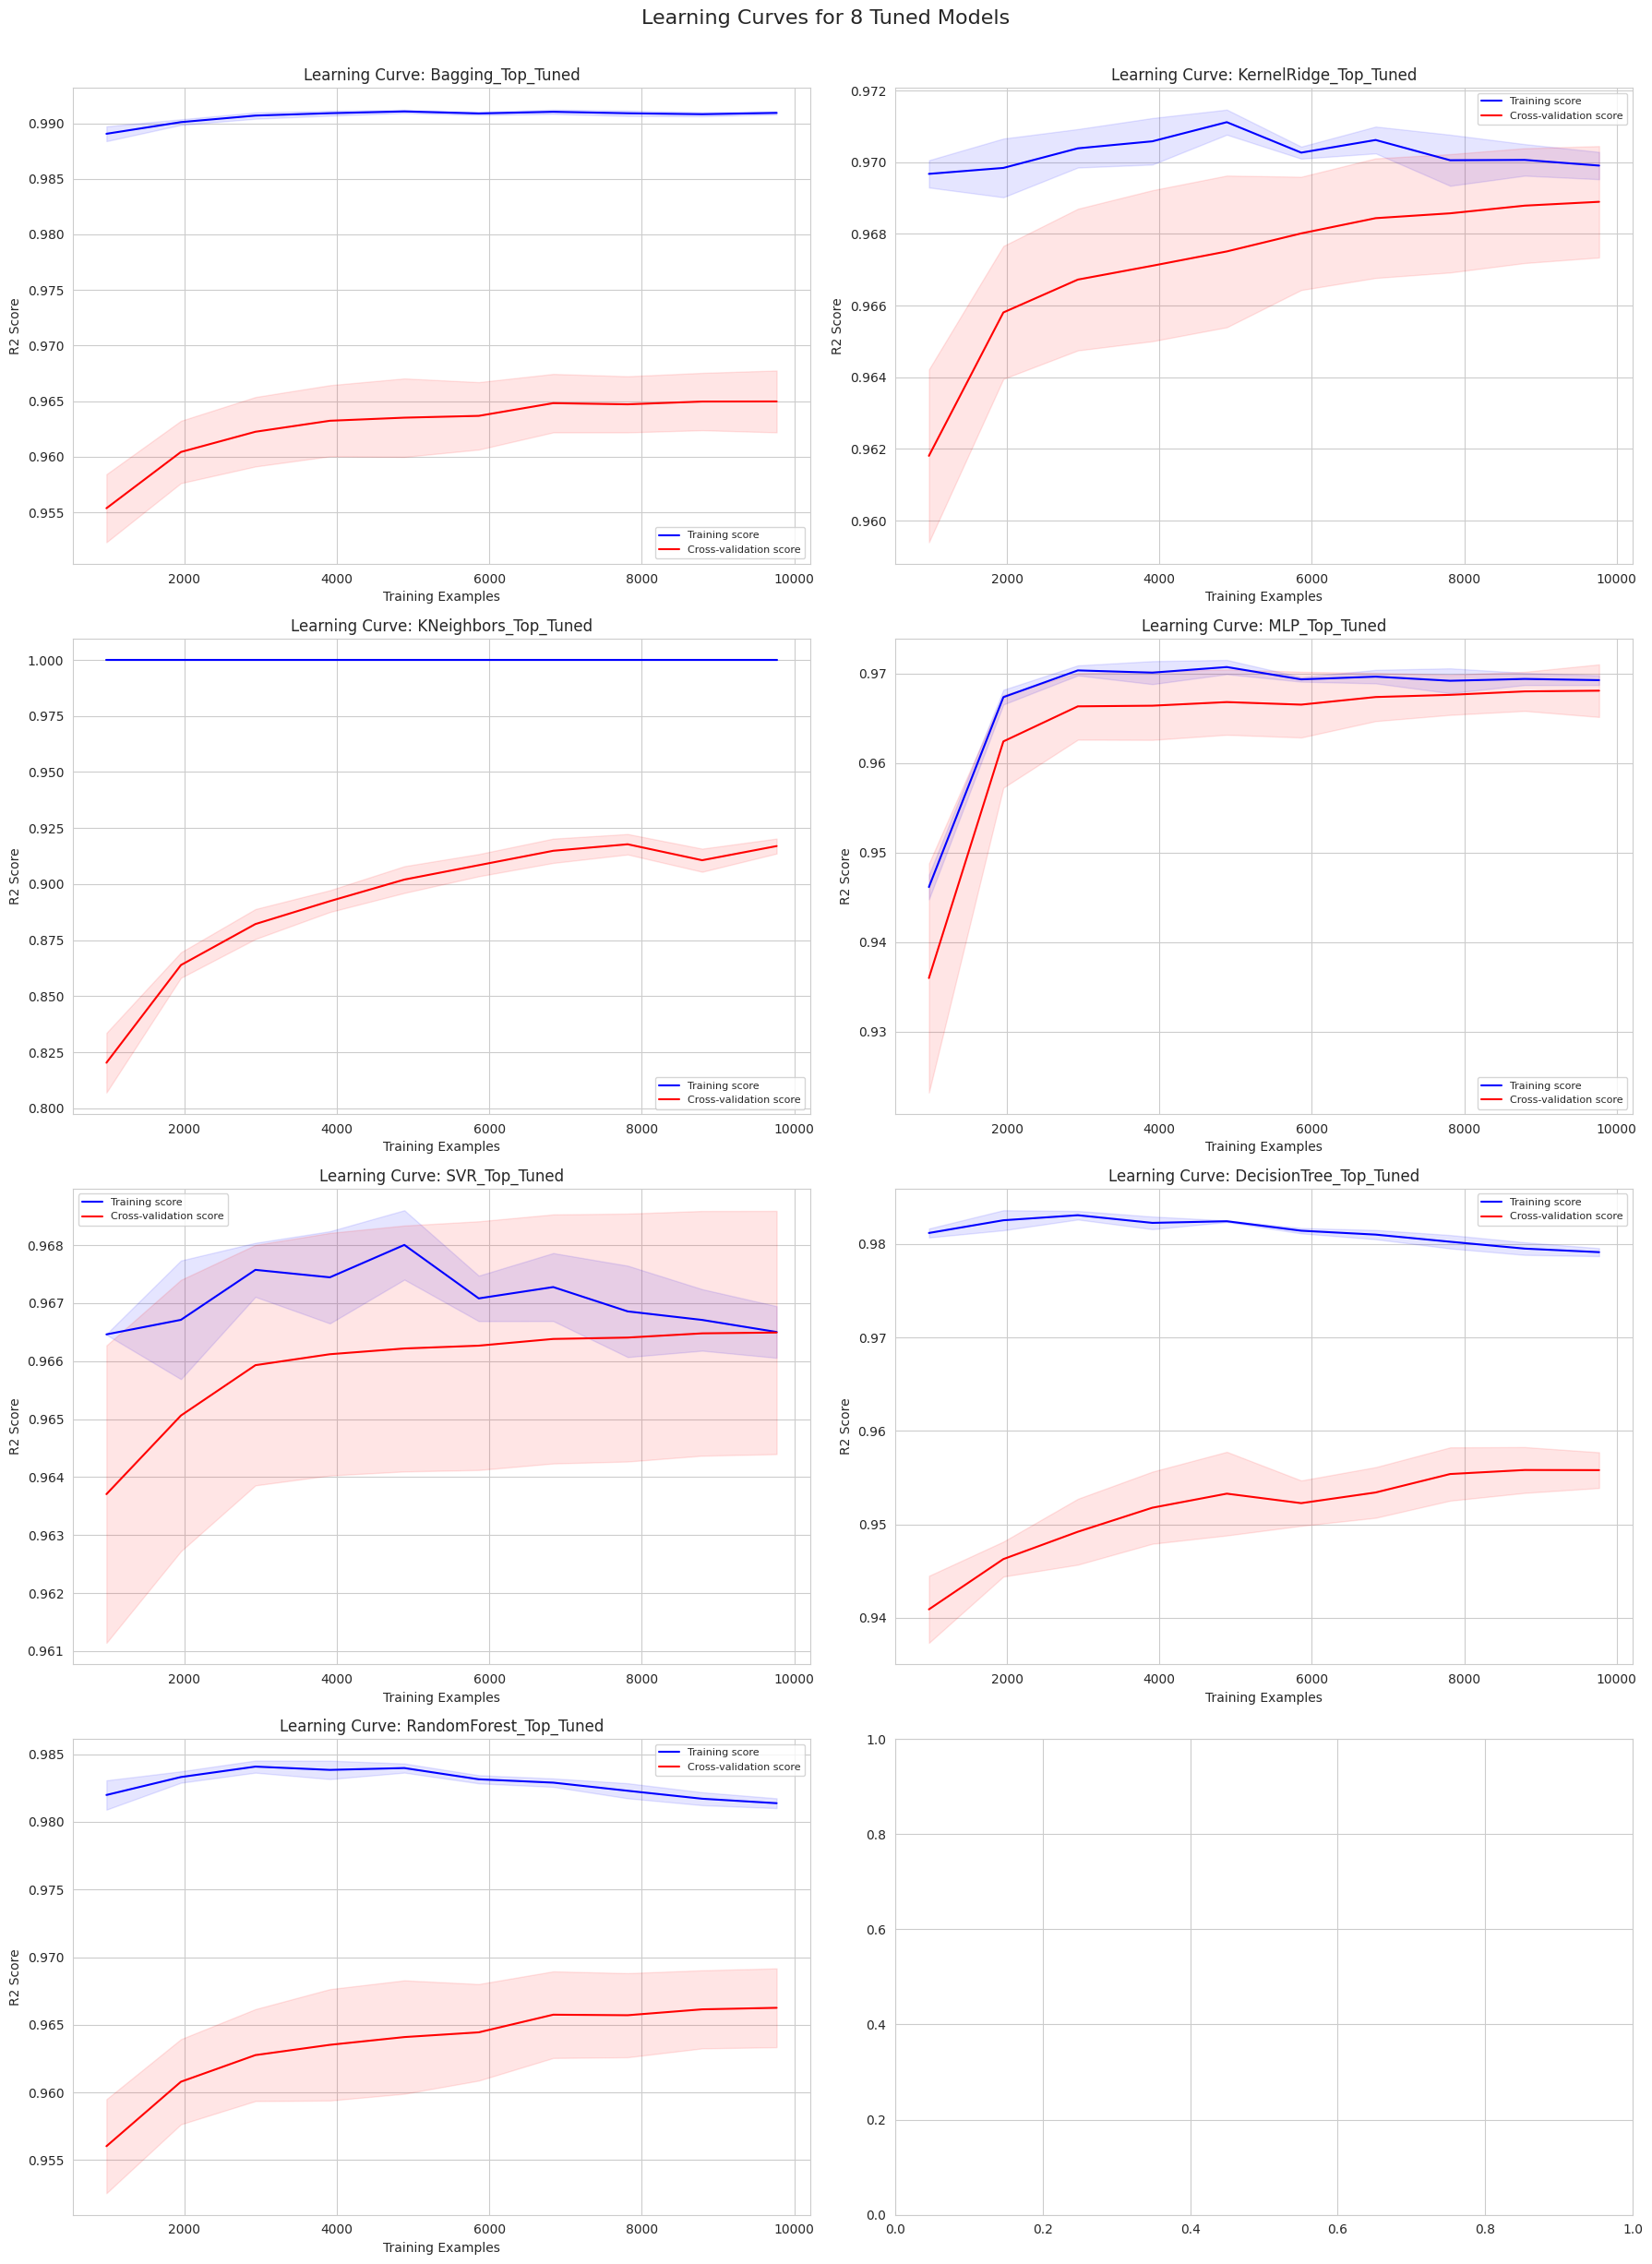

In [34]:
#@title  Visualización de los Resultados de Cross-Validation para los 8 Modelos Tuned
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")

# Prepare data for learning curves
X_lc = X_combined_train_val
y_lc = y_combined_train_val

# Get the 8 optimized models
models_for_lc = optimized_top_models

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten() # Flatten the 4x2 array of axes for easy iteration

for i, (name, model_instance) in enumerate(models_for_lc.items()):
    if i >= len(axes): # Ensure we don't try to plot more than available subplots
        break

    print(f"Generating learning curve for {name}...")

    # Create a pipeline for learning curve generation
    pipeline_lc = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("model", model_instance)
    ])

    # Calculate learning curve data
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=pipeline_lc,
        X=X_lc,
        y=y_lc,
        cv=5, # 5-fold cross-validation
        n_jobs=-1, # Use all available cores
        train_sizes=np.linspace(0.1, 1.0, 10), # 10 different sizes of training set
        scoring='r2' # Metric to evaluate
    )

    # Calculate mean and standard deviation for training and validation scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    ax = axes[i]

    # Plot learning curve
    ax.plot(train_sizes, train_scores_mean, label="Training score", color='blue')
    ax.plot(train_sizes, val_scores_mean, label="Cross-validation score", color='red')

    # Plot fill between for standard deviation (optional, but good for visualization)
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color='red')

    ax.set_title(f'Learning Curve: {name}', fontsize=12)
    ax.set_xlabel('Training Examples', fontsize=10)
    ax.set_ylabel('R2 Score', fontsize=10)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.suptitle('Learning Curves for 8 Tuned Models', y=1.02, fontsize=16) # Overall title
plt.show()


# 17. Ensambles simples

- Averaging
- Weighted Averaging

In [104]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("### Implementing Simple Ensembles: Averaging and Weighted Averaging")

# 1. Define estimators for VotingRegressor
# These estimators should be the fitted pipelines for the optimized models
estimators = []
for name, pipeline in re_tuned_pipelines.items():
    estimators.append((name, pipeline))

# --- Simple Averaging Ensemble (Equal Weights) ---
print("\n--- Simple Averaging Ensemble (Equal Weights) ---")
# Weights are implicitly equal if not specified, or can be set as [1, 1, ..., 1]
averaging_ensemble = VotingRegressor(estimators=estimators, n_jobs=-1)

# Fit and evaluate
start_time_avg = time.time()
averaging_ensemble.fit(X_train, y_train)
train_time_avg = time.time() - start_time_avg

pred_train_avg = averaging_ensemble.predict(X_train)
pred_val_avg   = averaging_ensemble.predict(X_val)
pred_test_avg  = averaging_ensemble.predict(X_test)

r2_train_avg = r2_score(y_train, pred_train_avg)
r2_val_avg = r2_score(y_val, pred_val_avg)
r2_test_avg = r2_score(y_test, pred_test_avg)

rmse_train_avg = np.sqrt(mean_squared_error(y_train, pred_train_avg))
rmse_val_avg = np.sqrt(mean_squared_error(y_val, pred_val_avg))
rmse_test_avg = np.sqrt(mean_squared_error(y_test, pred_test_avg))

mae_train_avg = mean_absolute_error(y_train, pred_train_avg)
mae_val_avg = mean_absolute_error(y_val, pred_val_avg)
mae_test_avg = mean_absolute_error(y_test, pred_test_avg)

averaging_results = {
    "Model": "Averaging_Ensemble",
    "Family": "Ensemble",
    "R2_Train": r2_train_avg,
    "R2_Val": r2_val_avg,
    "R2_Test": r2_test_avg,
    "RMSE_Train": rmse_train_avg,
    "RMSE_Val": rmse_val_avg,
    "RMSE_Test": rmse_test_avg,
    "MAE_Train": mae_train_avg,
    "MAE_Val": mae_val_avg,
    "MAE_Test": mae_test_avg,
    "Training_Time": train_time_avg,
    "Best_Params": "Equal weights"
}
print(pd.DataFrame([averaging_results]))

# --- Weighted Averaging Ensemble ---
print("\n--- Weighted Averaging Ensemble ---")
# Get R2_Test scores for the optimized models to use as weights
model_r2_tests = {}
for name in re_tuned_pipelines.keys():
    # Find the corresponding R2_Test from ranking_global
    # Use .get(name, 0.0) to handle cases where a model might not be in ranking_global (shouldn't happen here, but good practice)
    r2_test_score = ranking_global[ranking_global['Model'] == name]['R2_Test'].iloc[0] if name in ranking_global['Model'].values else 0.0
    model_r2_tests[name] = r2_test_score

# Create weights - ensure the order matches the estimators list
weights = [model_r2_tests[name] for name, _ in estimators]

weighted_averaging_ensemble = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)

# Fit and evaluate
start_time_w_avg = time.time()
weighted_averaging_ensemble.fit(X_train, y_train)
train_time_w_avg = time.time() - start_time_w_avg

pred_train_w_avg = weighted_averaging_ensemble.predict(X_train)
pred_val_w_avg   = weighted_averaging_ensemble.predict(X_val)
pred_test_w_avg  = weighted_averaging_ensemble.predict(X_test)

r2_train_w_avg = r2_score(y_train, pred_train_w_avg)
r2_val_w_avg = r2_score(y_val, pred_val_w_avg)
r2_test_w_avg = r2_score(y_test, pred_test_w_avg)

rmse_train_w_avg = np.sqrt(mean_squared_error(y_train, pred_train_w_avg))
rmse_val_w_avg = np.sqrt(mean_squared_error(y_val, pred_val_w_avg))
rmse_test_w_avg = np.sqrt(mean_squared_error(y_test, pred_test_w_avg))

mae_train_w_avg = mean_absolute_error(y_train, pred_train_w_avg)
mae_val_w_avg = mean_absolute_error(y_val, pred_val_w_avg)
mae_test_w_avg = mean_absolute_error(y_test, pred_test_w_avg)

weighted_averaging_results = {
    "Model": "Weighted_Averaging_Ensemble",
    "Family": "Ensemble",
    "R2_Train": r2_train_w_avg,
    "R2_Val": r2_val_w_avg,
    "R2_Test": r2_test_w_avg,
    "RMSE_Train": rmse_train_w_avg,
    "RMSE_Val": rmse_val_w_avg,
    "RMSE_Test": rmse_test_w_avg,
    "MAE_Train": mae_train_w_avg,
    "MAE_Val": mae_val_w_avg,
    "MAE_Test": mae_test_w_avg,
    "Training_Time": train_time_w_avg,
    "Best_Params": "Weights based on R2_Test"
}
print(pd.DataFrame([weighted_averaging_results]))

# Update the global ranking with the new ensemble models
new_ensemble_results_df = pd.DataFrame([averaging_results, weighted_averaging_results])

# Ensure 'Best_Params' column exists in results_df before concatenation
if 'Best_Params' not in results_df.columns:
    results_df['Best_Params'] = None

# Remove existing ensemble results if the cell is re-run
results_df = results_df[~results_df['Model'].isin(new_ensemble_results_df['Model'])]

results_df = pd.concat([results_df, new_ensemble_results_df], ignore_index=True)

# Update family_map for ensembles
family_map["Averaging_Ensemble"] = "Ensemble"
family_map["Weighted_Averaging_Ensemble"] = "Ensemble"
results_df["Family"] = results_df["Model"].map(family_map)

# Re-calculate ranks for the combined DataFrame
results_df["Gap_Train_Val"]=(results_df["R2_Train"]-results_df["R2_Val"]).abs()
results_df["Gap_Train_Test"]=(results_df["R2_Train"]-results_df["R2_Test"]).abs()
results_df["Gap_Val_Test"]=(results_df["R2_Val"]-results_df["R2_Test"]).abs()

higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=False,method="min")

for m in lower_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in results_df.columns if c.startswith("Rank_")]

results_df["Rank_Sum"]=results_df[rank_cols].sum(axis=1)

results_df["Global_Rank"]=results_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

ranking_global = results_df.sort_values("Global_Rank")

# Filter ranking_global to include only the 8 tuned algorithms
tuned_model_names = list(optimized_top_models.keys())
filtered_ranking_df = ranking_global[ranking_global['Model'].isin(tuned_model_names)].copy()

# Re-calculate ranks for this specific subset of 8 models
higher_better_subset=["R2_Train","R2_Val","R2_Test"]
lower_better_subset=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better_subset:
    filtered_ranking_df[f"Rank_{m}"]=filtered_ranking_df[m].rank(ascending=False,method="min")

for m in lower_better_subset:
    filtered_ranking_df[f"Rank_{m}"]=filtered_ranking_df[m].rank(ascending=True,method="min")

rank_cols_subset=[c for c in filtered_ranking_df.columns if c.startswith("Rank_")]

filtered_ranking_df["Rank_Sum"]=filtered_ranking_df[rank_cols_subset].sum(axis=1)

filtered_ranking_df["Global_Rank"]=filtered_ranking_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

# Sort the DataFrame by the new Global_Rank
new_ranking_df = filtered_ranking_df.sort_values("Global_Rank").reset_index(drop=True)

print("\n--- Global Ranking with Only 8 Tuned Models ---")
display(new_ranking_df[[
    "Model",
    "Family",
    "R2_Train", "R2_Val", "R2_Test",
    "Global_Rank"
]])

### Implementing Simple Ensembles: Averaging and Weighted Averaging

--- Simple Averaging Ensemble (Equal Weights) ---
                Model    Family  R2_Train    R2_Val   R2_Test  RMSE_Train  \
0  Averaging_Ensemble  Ensemble  0.984052  0.963589  0.970075   16.725572   

    RMSE_Val  RMSE_Test  MAE_Train    MAE_Val   MAE_Test  Training_Time  \
0  26.259587  23.650289  11.442447  17.216924  16.150908      66.727408   

     Best_Params  
0  Equal weights  

--- Weighted Averaging Ensemble ---
                         Model    Family  R2_Train    R2_Val   R2_Test  \
0  Weighted_Averaging_Ensemble  Ensemble   0.98382  0.963589  0.970066   

   RMSE_Train  RMSE_Val  RMSE_Test  MAE_Train  MAE_Val   MAE_Test  \
0   16.846843  26.25971   23.65354  11.510399    17.18  16.133439   

   Training_Time               Best_Params  
0      69.139849  Weights based on R2_Test  

--- Global Ranking with Only 8 Tuned Models ---


,Model,Family,R2_Train,R2_Val,R2_Test,Global_Rank
0,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,1.0
1,CatBoost_Top_Tuned,Boosting,0.971672,0.961308,0.969903,2.0
2,RandomForest_Top_Tuned,Tree-Ensemble,0.982648,0.962011,0.970216,3.0
3,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,4.0
4,MLP_Top_Tuned,Neural Network,0.968179,0.963423,0.969346,5.0
5,Bagging_Top_Tuned,Bagging,0.990957,0.960807,0.969107,6.0
6,DecisionTree_Top_Tuned,Tree,0.980212,0.951898,0.962016,7.0
7,KNeighbors_Top_Tuned,Neighbors,1.000000,0.914223,0.922956,8.0


# 18. Ensambles homogéneos

- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting

In [23]:
print("### Implementing Homogeneous Ensembles using Tuned Models")

# Get the already tuned homogeneous ensembles from the optimized_top_models
# These are Bagging_Top_Tuned and RandomForest_Top_Tuned
bagging_tuned_pipeline = re_tuned_pipelines['Bagging_Top_Tuned']
random_forest_tuned_pipeline = re_tuned_pipelines['RandomForest_Top_Tuned']

# Prepare the models for evaluation by extracting the 'model' object from the pipelines
# Note: evaluate_model expects the raw model, not the full pipeline. It wraps it in a new pipeline.
# So we need to get the actual regressor object from the stored pipelines.

# Extract the actual model instance from the pipeline for existing tuned ensembles
bagging_model_instance = bagging_tuned_pipeline.named_steps['model']
random_forest_model_instance = random_forest_tuned_pipeline.named_steps['model']

# Create a new homogeneous ensemble: Bagging with DecisionTree_Top_Tuned as base estimator
dt_tuned_model_instance = re_tuned_pipelines['DecisionTree_Top_Tuned'].named_steps['model']

# For the new Bagging, we use the optimized DecisionTree as base_estimator
# The number of estimators and other parameters can be tuned or set reasonably.
# For simplicity, let's use default n_estimators for Bagging.
bagging_dt_ensemble_model = BaggingRegressor(estimator=dt_tuned_model_instance, n_estimators=50, random_state=42)

homogeneous_ensembles_to_evaluate = {
    "Bagging_Top_Tuned": bagging_model_instance,
    "RandomForest_Top_Tuned": random_forest_model_instance,
    "Bagging_DecisionTree_Ensemble": bagging_dt_ensemble_model
}

new_homogeneous_ensemble_results = []
new_homogeneous_ensemble_pipelines = {}

print("\nEvaluating homogeneous ensembles...")

for name, model_instance in homogeneous_ensembles_to_evaluate.items():
    if name not in ["Bagging_Top_Tuned", "RandomForest_Top_Tuned"]:
        print(f"Evaluating new homogeneous ensemble: {name}...")
        try:
            # The evaluate_model function already creates a pipeline, so we pass the raw model instance
            result, pipe = evaluate_model(name, model_instance)
            new_homogeneous_ensemble_results.append(result)
            new_homogeneous_ensemble_pipelines[name] = pipe
            print(f"Finished evaluating {name}.")
        except Exception as e:
            print(f"Homogeneous Ensemble {name}: ERROR -> {e}")
    else:
        # For models already in re_tuned_pipelines, we just retrieve their previous results
        # and add them to the new_homogeneous_ensemble_results list if they are not already there
        # (to avoid re-evaluating or duplicating)
        existing_result = ranking_global[ranking_global['Model'] == name].iloc[0].to_dict()
        if name not in [res['Model'] for res in new_homogeneous_ensemble_results]:
            new_homogeneous_ensemble_results.append(existing_result)
            new_homogeneous_ensemble_pipelines[name] = re_tuned_pipelines[name]
        print(f"Included existing results for {name}.")

# Convert results to a DataFrame
homogeneous_results_df = pd.DataFrame(new_homogeneous_ensemble_results)

# Update the global ranking with the new homogeneous ensemble models
# Ensure 'Best_Params' column exists in results_df before concatenation
if 'Best_Params' not in results_df.columns:
    results_df['Best_Params'] = None

# Add 'Best_Params' column to homogeneous_results_df if it's missing (for the new ensemble)
if 'Best_Params' not in homogeneous_results_df.columns:
    homogeneous_results_df['Best_Params'] = None

# Remove existing homogeneous ensemble results if the cell is re-run (Bagging_DecisionTree_Ensemble)
results_df = results_df[~results_df['Model'].isin(homogeneous_results_df['Model'])]

results_df = pd.concat([results_df, homogeneous_results_df], ignore_index=True)

# Update family_map for ensembles
family_map["Bagging_DecisionTree_Ensemble"] = "Ensemble"
results_df["Family"] = results_df["Model"].map(family_map)

# Re-calculate ranks for the combined DataFrame
results_df["Gap_Train_Val"]=(results_df["R2_Train"]-results_df["R2_Val"]).abs()
results_df["Gap_Train_Test"]=(results_df["R2_Train"]-results_df["R2_Test"]).abs()
results_df["Gap_Val_Test"]=(results_df["R2_Val"]-results_df["R2_Test"]).abs()

higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=False,method="min")

for m in lower_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in results_df.columns if c.startswith("Rank_")]

results_df["Rank_Sum"]=results_df[rank_cols].sum(axis=1)

results_df["Global_Rank"]=results_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

ranking_global = results_df.sort_values("Global_Rank")

print("\n--- Global Ranking with Homogeneous Ensembles --- ")
# Display only the relevant homogeneous ensembles and the existing 8 tuned models for context
display_models = list(optimized_top_models.keys()) + ["Bagging_DecisionTree_Ensemble"]
filtered_ranking = ranking_global[ranking_global['Model'].isin(display_models)].copy()

# Re-calculate ranks for this specific subset of models (tuned + new homogeneous ensemble)
higher_better_subset=["R2_Train","R2_Val","R2_Test"]
lower_better_subset=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better_subset:
    filtered_ranking[f"Rank_{m}"]=filtered_ranking[m].rank(ascending=False,method="min")

for m in lower_better_subset:
    filtered_ranking[f"Rank_{m}"]=filtered_ranking[m].rank(ascending=True,method="min")

rank_cols_subset=[c for c in filtered_ranking.columns if c.startswith("Rank_")]

filtered_ranking["Rank_Sum"]=filtered_ranking[rank_cols_subset].sum(axis=1)

filtered_ranking["Global_Rank"]=filtered_ranking["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

filtered_ranking = filtered_ranking.sort_values("Global_Rank").reset_index(drop=True)

display(filtered_ranking[[
    "Model",
    "Family",
    "R2_Train", "R2_Val", "R2_Test",
    "Global_Rank"
]])


### Implementing Homogeneous Ensembles using Tuned Models

Evaluating homogeneous ensembles...
Included existing results for Bagging_Top_Tuned.
Included existing results for RandomForest_Top_Tuned.
Evaluating new homogeneous ensemble: Bagging_DecisionTree_Ensemble...
Finished evaluating Bagging_DecisionTree_Ensemble.

--- Global Ranking with Homogeneous Ensembles --- 


,Model,Family,R2_Train,R2_Val,R2_Test,Global_Rank
0,Bagging_DecisionTree_Ensemble,Ensemble,0.981858,0.961821,0.969918,1.0
1,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,2.0
2,MLP_Top_Tuned,Neural Network,0.970066,0.965130,0.970842,3.0
3,RandomForest_Top_Tuned,Tree-Ensemble,0.982667,0.962142,0.970093,4.0
4,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,5.0
5,Bagging_Top_Tuned,Bagging,0.991160,0.960793,0.968829,6.0
6,DecisionTree_Top_Tuned,Tree,0.980212,0.952132,0.961907,7.0
7,KNeighbors_Top_Tuned,Neighbors,1.000000,0.914223,0.922956,8.0


# 19. Ensambles heterogéneos

- Voting Regressor
- Stacking Regressor
- Blending

In [107]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression # For meta-estimator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold # For StackingRegressor CV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

print("### Implementing Heterogeneous Ensembles")

# --- Stacking Regressor ---
print("\n--- Stacking Regressor ---")

# Get the 8 tuned model pipelines as base estimators
stack_estimators = []
for name, pipeline in re_tuned_pipelines.items():
    # StackingRegressor expects unfitted estimators if 'passthrough' is False, and will fit them
    # internally on training folds. For re_tuned_pipelines, we have fitted pipelines.
    # To pass unfitted estimators (as recommended for StackingRegressor's internal CV),
    # we need to re-instantiate the base models with their best parameters.
    # The 'optimized_top_models' dictionary already holds these unfitted instances.
    if name in optimized_top_models:
        # Get the unfitted model instance with best params from optimized_top_models
        model_instance = optimized_top_models[name]
        # Create a new pipeline for stacking, similar to how evaluate_model works
        base_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
            ("model", model_instance)
        ])
        stack_estimators.append((name, base_pipeline))
    else:
        print(f"Warning: Model {name} not found in optimized_top_models. Skipping for stacking.")

# Check if stack_estimators is empty after the loop
if not stack_estimators:
    raise ValueError("No base estimators were added to stack_estimators. Cannot create StackingRegressor.")

# Define the meta-estimator
meta_estimator = Ridge(random_state=42)

stacking_ensemble = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=meta_estimator,
    cv=5, # 5-fold cross-validation for training the meta-estimator
    n_jobs=-1,
    passthrough=False # Do not pass original features to final_estimator
)

start_time_stack = time.time()
stacking_ensemble.fit(X_train, y_train)
train_time_stack = time.time() - start_time_stack

pred_train_stack = stacking_ensemble.predict(X_train)
pred_val_stack   = stacking_ensemble.predict(X_val)
pred_test_stack  = stacking_ensemble.predict(X_test)

stacking_results = {
    "Model": "Stacking_Ensemble",
    "Family": "Ensemble",
    "R2_Train": r2_score(y_train, pred_train_stack),
    "R2_Val": r2_score(y_val, pred_val_stack),
    "R2_Test": r2_score(y_test, pred_test_stack),
    "RMSE_Train": np.sqrt(mean_squared_error(y_train, pred_train_stack)),
    "RMSE_Val": np.sqrt(mean_squared_error(y_val, pred_val_stack)),
    "RMSE_Test": np.sqrt(mean_squared_error(y_test, pred_test_stack)),
    "MAE_Train": mean_absolute_error(y_train, pred_train_stack),
    "MAE_Val": mean_absolute_error(y_val, pred_val_stack),
    "MAE_Test": mean_absolute_error(y_test, pred_test_stack),
    "Training_Time": train_time_stack,
    "Best_Params": "Meta-estimator: Ridge"
}
print(pd.DataFrame([stacking_results]))

# --- Blending Ensemble ---
print("\n--- Blending Ensemble ---")

# 1. Generate meta-features from base models on X_val for meta-learner training
blending_X_meta_train = pd.DataFrame()
for name, pipeline in re_tuned_pipelines.items():
    blending_X_meta_train[name] = pipeline.predict(X_val)

blending_y_meta_train = y_val

# 2. Train meta-learner on meta-features from X_val
blending_meta_learner = Ridge(random_state=42)
start_time_blend_meta = time.time()
blending_meta_learner.fit(blending_X_meta_train, blending_y_meta_train)
time_blend_meta = time.time() - start_time_blend_meta

# 3. Generate meta-features from base models on X_test for final prediction
blending_X_meta_test = pd.DataFrame()
for name, pipeline in re_tuned_pipelines.items():
    blending_X_meta_test[name] = pipeline.predict(X_test)

# 4. Make final predictions using the meta-learner
blending_pred_test = blending_meta_learner.predict(blending_X_meta_test)

# To get R2_Train for blending, we apply base models to X_train and meta-learner to these predictions
blending_X_meta_train_on_train = pd.DataFrame()
for name, pipeline in re_tuned_pipelines.items():
    blending_X_meta_train_on_train[name] = pipeline.predict(X_train)
blending_pred_train = blending_meta_learner.predict(blending_X_meta_train_on_train)

blending_pred_val_meta = blending_meta_learner.predict(blending_X_meta_train) # Predictions on X_val used for meta-learner training

blending_results = {
    "Model": "Blending_Ensemble",
    "Family": "Ensemble",
    "R2_Train": r2_score(y_train, blending_pred_train),
    "R2_Val": r2_score(y_val, blending_pred_val_meta),
    "R2_Test": r2_score(y_test, blending_pred_test),
    "RMSE_Train": np.sqrt(mean_squared_error(y_train, blending_pred_train)),
    "RMSE_Val": np.sqrt(mean_squared_error(y_val, blending_pred_val_meta)),
    "RMSE_Test": np.sqrt(mean_squared_error(y_test, blending_pred_test)),
    "MAE_Train": mean_absolute_error(y_train, blending_pred_train),
    "MAE_Val": mean_absolute_error(y_val, blending_pred_val_meta),
    "MAE_Test": mean_absolute_error(y_test, blending_pred_test),
    "Training_Time": train_time_stack + time_blend_meta, # Sum of base model training (from stacking fit) + meta-learner
    "Best_Params": "Meta-learner: Ridge, trained on Val predictions"
}
print(pd.DataFrame([blending_results]))

# --- Update Global Ranking with New Ensemble Models ---
new_ensemble_results_df = pd.DataFrame([stacking_results, blending_results])

# Ensure 'Best_Params' column exists in results_df before concatenation
if 'Best_Params' not in results_df.columns:
    results_df['Best_Params'] = None

# Remove existing ensemble results if the cell is re-run
results_df = results_df[~results_df['Model'].isin(new_ensemble_results_df['Model'])]

results_df = pd.concat([results_df, new_ensemble_results_df], ignore_index=True)

# Update family_map for ensembles
family_map["Stacking_Ensemble"] = "Ensemble"
family_map["Blending_Ensemble"] = "Ensemble"
results_df["Family"] = results_df["Model"].map(family_map)

# Re-calculate ranks for the combined DataFrame
results_df["Gap_Train_Val"]=(results_df["R2_Train"]-results_df["R2_Val"]).abs()
results_df["Gap_Train_Test"]=(results_df["R2_Train"]-results_df["R2_Test"]).abs()
results_df["Gap_Val_Test"]=(results_df["R2_Val"]-results_df["R2_Test"]).abs()

higher_better=["R2_Train","R2_Val","R2_Test"]
lower_better=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=False,method="min")

for m in lower_better:
    results_df[f"Rank_{m}"]=results_df[m].rank(ascending=True,method="min")

rank_cols=[c for c in results_df.columns if c.startswith("Rank_")]

results_df["Rank_Sum"]=results_df[rank_cols].sum(axis=1)

results_df["Global_Rank"]=results_df["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

ranking_global = results_df.sort_values("Global_Rank")

print("\n--- Global Ranking with All Ensembles and Tuned Models ---")
# Display only the relevant ensembles and the existing 8 tuned models for context
display_models = list(optimized_top_models.keys()) + \
                 ["Bagging_DecisionTree_Ensemble", "Averaging_Ensemble", \
                  "Weighted_Averaging_Ensemble", "Stacking_Ensemble", "Blending_Ensemble"]
filtered_ranking = ranking_global[ranking_global['Model'].isin(display_models)].copy()

# Re-calculate ranks for this specific subset of models (tuned + all ensembles)
higher_better_subset=["R2_Train","R2_Val","R2_Test"]
lower_better_subset=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better_subset:
    filtered_ranking[f"Rank_{m}"]=filtered_ranking[m].rank(ascending=False,method="min")

for m in lower_better_subset:
    filtered_ranking[f"Rank_{m}"]=filtered_ranking[m].rank(ascending=True,method="min")

rank_cols_subset=[c for c in filtered_ranking.columns if c.startswith("Rank_")]

filtered_ranking["Rank_Sum"]=filtered_ranking[rank_cols_subset].sum(axis=1)

filtered_ranking["Global_Rank"]=filtered_ranking["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

filtered_ranking = filtered_ranking.sort_values("Global_Rank").reset_index(drop=True)

display(filtered_ranking[[
    "Model",
    "Family",
    "R2_Train", "R2_Val", "R2_Test",
    "Global_Rank"
]])

### Implementing Heterogeneous Ensembles

--- Stacking Regressor ---
               Model    Family  R2_Train    R2_Val   R2_Test  RMSE_Train  \
0  Stacking_Ensemble  Ensemble  0.971396  0.965989  0.971766   22.399393   

    RMSE_Val  RMSE_Test  MAE_Train    MAE_Val   MAE_Test  Training_Time  \
0  25.379302  22.972319  15.265083  16.452788  15.556065     299.084748   

             Best_Params  
0  Meta-estimator: Ridge  

--- Blending Ensemble ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valid

               Model    Family  R2_Train    R2_Val   R2_Test  RMSE_Train  \
0  Blending_Ensemble  Ensemble  0.611448  0.630057  0.643429   82.555715   

    RMSE_Val  RMSE_Test  MAE_Train    MAE_Val   MAE_Test  Training_Time  \
0  83.702736  81.637525  63.679878  63.833084  62.588907     299.087978   

                                       Best_Params  
0  Meta-learner: Ridge, trained on Val predictions  

--- Global Ranking with All Ensembles and Tuned Models ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


,Model,Family,R2_Train,R2_Val,R2_Test,Global_Rank
0,Stacking_Ensemble,Ensemble,0.971396,0.965989,0.971766,1.0
1,Bagging_DecisionTree_Ensemble,Ensemble,0.981858,0.961821,0.969918,2.0
2,Blending_Ensemble,Ensemble,0.611448,0.630057,0.643429,3.0
3,Averaging_Ensemble,Ensemble,0.984052,0.963589,0.970075,4.0
4,Weighted_Averaging_Ensemble,Ensemble,0.983820,0.963589,0.970066,5.0
5,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,6.0
6,CatBoost_Top_Tuned,Boosting,0.971672,0.961308,0.969903,7.0
7,RandomForest_Top_Tuned,Tree-Ensemble,0.982648,0.962011,0.970216,8.0
8,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,9.0
9,MLP_Top_Tuned,Neural Network,0.968179,0.963423,0.969346,10.0


# **20. Comparación final de modelos**

Con el propósito de seleccionar la mejor alternativa para la estimación de CO₂eA, se realizó una comparación final entre los modelos optimizados y los diferentes esquemas de ensamble desarrollados durante la actividad. El análisis incluyó los algoritmos ajustados mediante optimización de hiperparámetros y los modelos de ensamble construidos a partir de ellos, tales como Averaging, Weighted Averaging, Stacking, Blending y Bagging. Para garantizar una evaluación homogénea, se recalcularon los rankings considerando simultáneamente las métricas de desempeño en entrenamiento, validación y prueba (R², RMSE y MAE), los indicadores de generalización y el tiempo de entrenamiento. Posteriormente, se generó un ranking global basado en la suma de posiciones (Rank Sum), permitiendo identificar los modelos con mejor equilibrio entre precisión, estabilidad y eficiencia computacional. Esta comparación constituye la etapa culminante del proceso de modelado y proporciona la evidencia cuantitativa necesaria para justificar la selección del modelo final que mejor satisface los objetivos del proyecto y las necesidades del problema de negocio.

In [110]:
#@title Comparación final de modelos
print("\n--- Consolidated Global Ranking (Tuned Models & Ensembles) ---")

# Filter to include only the 8 tuned models and the ensemble models
# 'optimized_top_models' contains the names of the 8 tuned models
display_models_names = list(optimized_top_models.keys()) + \
                       ["Averaging_Ensemble", "Weighted_Averaging_Ensemble", \
                        "Stacking_Ensemble", "Blending_Ensemble", "Bagging_DecisionTree_Ensemble"]

filtered_ranking_for_display = ranking_global[ranking_global['Model'].isin(display_models_names)].copy()

# Re-calculate ranks for this specific subset of models
higher_better_subset=["R2_Train","R2_Val","R2_Test"]
lower_better_subset=["RMSE_Train","RMSE_Val","RMSE_Test",
               "MAE_Train","MAE_Val","MAE_Test",
               "Gap_Train_Val","Gap_Train_Test","Gap_Val_Test",
               "Training_Time"]

for m in higher_better_subset:
    filtered_ranking_for_display[f"Rank_{m}"]=filtered_ranking_for_display[m].rank(ascending=False,method="min")

for m in lower_better_subset:
    filtered_ranking_for_display[f"Rank_{m}"]=filtered_ranking_for_display[m].rank(ascending=True,method="min")

rank_cols_subset=[c for c in filtered_ranking_for_display.columns if c.startswith("Rank_")]

filtered_ranking_for_display["Rank_Sum"]=filtered_ranking_for_display[rank_cols_subset].sum(axis=1)

filtered_ranking_for_display["Global_Rank"]=filtered_ranking_for_display["Rank_Sum"].rank(
    ascending=True,
    method="min"
)

filtered_ranking_for_display = filtered_ranking_for_display.sort_values("Global_Rank").reset_index(drop=True)

display(filtered_ranking_for_display[[
    "Model",
    "Family",
    "R2_Train", "R2_Val", "R2_Test",
    "RMSE_Test",
    "MAE_Test",
    "Training_Time",
    "Global_Rank"
]])


--- Consolidated Global Ranking (Tuned Models & Ensembles) ---


,Model,Family,R2_Train,R2_Val,R2_Test,RMSE_Test,MAE_Test,Training_Time,Global_Rank
0,Stacking_Ensemble,Ensemble,0.971396,0.965989,0.971766,22.972319,15.556065,299.084748,1.0
1,Bagging_DecisionTree_Ensemble,Ensemble,0.981858,0.961821,0.969918,23.712198,16.164121,5.343944,2.0
2,Blending_Ensemble,Ensemble,0.611448,0.630057,0.643429,81.637525,62.588907,299.087978,3.0
3,Averaging_Ensemble,Ensemble,0.984052,0.963589,0.970075,23.650289,16.150908,66.727408,4.0
4,Weighted_Averaging_Ensemble,Ensemble,0.983820,0.963589,0.970066,23.653540,16.133439,69.139849,5.0
5,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,23.089374,15.652459,12.344906,6.0
6,CatBoost_Top_Tuned,Boosting,0.971672,0.961308,0.969903,23.717924,15.923899,1.114516,7.0
7,RandomForest_Top_Tuned,Tree-Ensemble,0.982648,0.962011,0.970216,23.594514,16.047931,36.893067,8.0
8,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,24.203196,16.272707,3.493988,9.0
9,MLP_Top_Tuned,Neural Network,0.968179,0.963423,0.969346,23.936451,16.851981,20.812218,10.0


# **21. Selección del modelo final**
Con base en los resultados obtenidos durante las etapas de optimización y jerarquización, se seleccionaron cuatro modelos candidatos con desempeño sobresaliente para un análisis comparativo más detallado: MLP (Red Neuronal Artificial), Kernel Ridge, Support Vector Regression (SVR) y Random Forest. Estos algoritmos representan enfoques metodológicos distintos y mostraron una combinación favorable de precisión, capacidad de generalización y estabilidad durante las fases previas de evaluación. La comparación considera las métricas R², RMSE y MAE en los conjuntos de entrenamiento, validación y prueba, así como los indicadores de sobreajuste derivados de las diferencias entre dichos conjuntos y el tiempo requerido para el entrenamiento. Este análisis permite identificar las fortalezas y limitaciones de cada alternativa antes de su utilización en los esquemas de ensamble y facilita la selección del modelo final más adecuado para la estimación de CO₂eA. En particular, se espera que los modelos seleccionados presenten altos valores de R² en validación y prueba, errores reducidos y diferencias mínimas entre entrenamiento y evaluación, evidenciando una adecuada capacidad de generalización sobre datos no observados.

In [111]:
#@title Comparación final de modelos
print("\n--- Performance of Selected Tuned Models ---")

selected_models = [
    "MLP_Top_Tuned",
    "KernelRidge_Top_Tuned",
    "SVR_Top_Tuned",
    "RandomForest_Top_Tuned"
]

# Filter ranking_global to include only the selected models
filtered_selected_models_df = ranking_global[
    ranking_global['Model'].isin(selected_models)
].sort_values(by='Global_Rank').reset_index(drop=True)

display(filtered_selected_models_df[[
    "Model",
    "Family",
    "R2_Train", "R2_Val", "R2_Test",
    "RMSE_Train", "RMSE_Val", "RMSE_Test",
    "MAE_Train", "MAE_Val", "MAE_Test",
    "Gap_Train_Val", "Gap_Train_Test", "Gap_Val_Test",
    "Training_Time",
    "Global_Rank"
]])


--- Performance of Selected Tuned Models ---


,Model,Family,R2_Train,R2_Val,R2_Test,RMSE_Train,RMSE_Val,RMSE_Test,MAE_Train,MAE_Val,MAE_Test,Gap_Train_Val,Gap_Train_Test,Gap_Val_Test,Training_Time,Global_Rank
0,KernelRidge_Top_Tuned,Kernel,0.970667,0.966865,0.971477,22.683138,25.050468,23.089374,15.475683,16.429943,15.652459,0.003802,0.000811,0.004612,12.344906,6.0
1,RandomForest_Top_Tuned,Tree-Ensemble,0.982648,0.962011,0.970216,17.446241,26.822503,23.594514,12.031675,17.518964,16.047931,0.020636,0.012432,0.008204,36.893067,12.0
2,SVR_Top_Tuned,SVM,0.967297,0.964552,0.968659,23.950690,25.910154,24.203196,16.159582,16.980897,16.272707,0.002745,0.001362,0.004107,3.493988,14.0
3,MLP_Top_Tuned,Neural Network,0.968179,0.963423,0.969346,23.625243,26.319305,23.936451,16.774653,17.728495,16.851981,0.004756,0.001167,0.005923,20.812218,20.0


# **22. Interpretabilidad y visualizaciones**


1. Predicho vs Observado
2. Residuos vs Predicción
3. Histograma de residuos
4. Importancia de variables
5. SHAP Summary Plot (opcional)


In [26]:
#@title Grafica de valores Predichos vs Observados
import pandas as pd
import numpy as np

# Define the selected tuned models
selected_models = [
    "MLP_Top_Tuned",
    "KernelRidge_Top_Tuned",
    "SVR_Top_Tuned",
    "RandomForest_Top_Tuned"
]

# Initialize the DataFrame with observed values (y_test is already in original scale)
df_res = pd.DataFrame({'Observed_CO2eA': y_test.values})

print("Generating predictions and residuals for selected tuned models...")

for model_name in selected_models:
    if model_name in re_tuned_pipelines:
        pipeline = re_tuned_pipelines[model_name]

        # Predict on X_test
        y_pred = pipeline.predict(X_test)

        # Ensure predictions are non-negative, as CO2eA cannot be negative
        y_pred = np.maximum(0, y_pred)

        # Calculate residuals
        residuals = y_test.values - y_pred

        # Add predicted values and residuals to the DataFrame
        df_res[f'{model_name}_Predicted'] = y_pred
        df_res[f'{model_name}_Residuals'] = residuals
        print(f"Processed {model_name}")
    else:
        print(f"Warning: Model {model_name} not found in re_tuned_pipelines. Skipping.")

print("DataFrame with predictions and residuals generated successfully.")

# Display the head of the resulting DataFrame
display(df_res.head())

Generating predictions and residuals for selected tuned models...
Processed MLP_Top_Tuned
Processed KernelRidge_Top_Tuned
Processed SVR_Top_Tuned
Processed RandomForest_Top_Tuned
DataFrame with predictions and residuals generated successfully.


,Observed_CO2eA,MLP_Top_Tuned_Predicted,MLP_Top_Tuned_Residuals,KernelRidge_Top_Tuned_Predicted,KernelRidge_Top_Tuned_Residuals,SVR_Top_Tuned_Predicted,SVR_Top_Tuned_Residuals,RandomForest_Top_Tuned_Predicted,RandomForest_Top_Tuned_Residuals
0,174.898836,177.662272,-2.763436,170.969846,3.928990,174.816398,0.082438,175.712341,-0.813505
1,257.190168,261.074974,-3.884806,261.213581,-4.023413,262.144473,-4.954305,261.970184,-4.780017
2,252.594221,245.888390,6.705831,242.865333,9.728887,248.905056,3.689164,246.474074,6.120146
3,322.154401,269.508492,52.645910,270.062818,52.091583,267.580223,54.574178,267.683412,54.470989
4,258.637244,255.007400,3.629844,250.820763,7.816481,254.414182,4.223062,253.571564,5.065680


### Visualización de Predicciones vs Observaciones

A continuación, se visualiza la relación entre los valores observados y los valores predichos para cada uno de los modelos seleccionados. Idealmente, los puntos deberían agruparse cerca de la línea de 45 grados (y=x), indicando una predicción precisa.

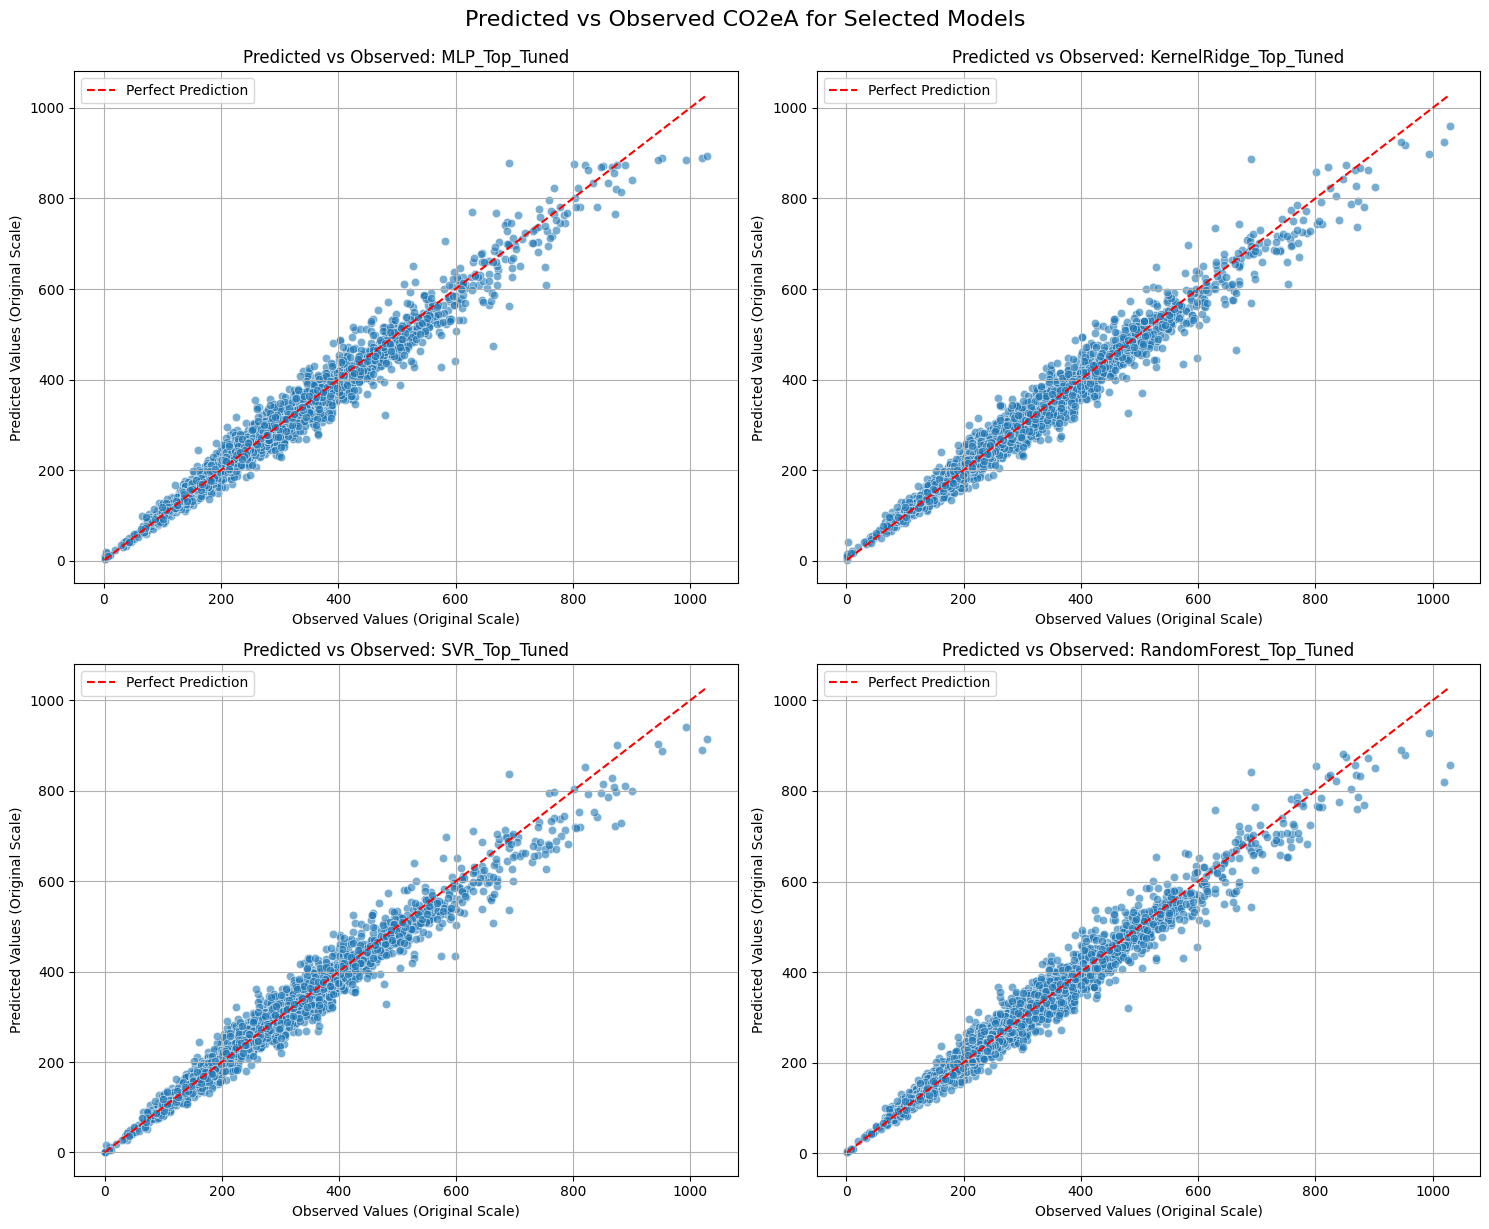

In [27]:
#@title  Visualización de Predicciones vs Observaciones
import matplotlib.pyplot as plt
import seaborn as sns

selected_models_for_plotting = [
    "MLP_Top_Tuned",
    "KernelRidge_Top_Tuned",
    "SVR_Top_Tuned",
    "RandomForest_Top_Tuned"
]

# Determine the number of rows and columns for the subplots
num_models = len(selected_models_for_plotting)
num_cols = 2 # Let's aim for 2 columns
num_rows = (num_models + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, model_name in enumerate(selected_models_for_plotting):
    ax = axes[i]

    # Plot Predicted vs Observed
    sns.scatterplot(
        x=df_res['Observed_CO2eA'],
        y=df_res[f'{model_name}_Predicted'],
        alpha=0.6,
        ax=ax
    )

    # Add a perfect prediction line (y=x)
    max_val = max(df_res['Observed_CO2eA'].max(), df_res[f'{model_name}_Predicted'].max())
    min_val = min(df_res['Observed_CO2eA'].min(), df_res[f'{model_name}_Predicted'].min())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    ax.set_title(f'Predicted vs Observed: {model_name}')
    ax.set_xlabel('Observed Values (Original Scale)')
    ax.set_ylabel('Predicted Values (Original Scale)')
    ax.legend()
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Predicted vs Observed CO2eA for Selected Models', y=1.02, fontsize=16)
plt.show()

### Análisis de Residuos vs Predicciones

Para entender mejor el comportamiento de los errores de cada modelo, se graficarán los residuos (diferencia entre el valor observado y el predicho) contra los valores predichos. Un patrón aleatorio en este gráfico indica que el modelo es apropiado y que los errores no están correlacionados con la magnitud de las predicciones. La presencia de patrones, como una forma de embudo o curvas, puede indicar problemas de heterocedasticidad o sesgo en el modelo.

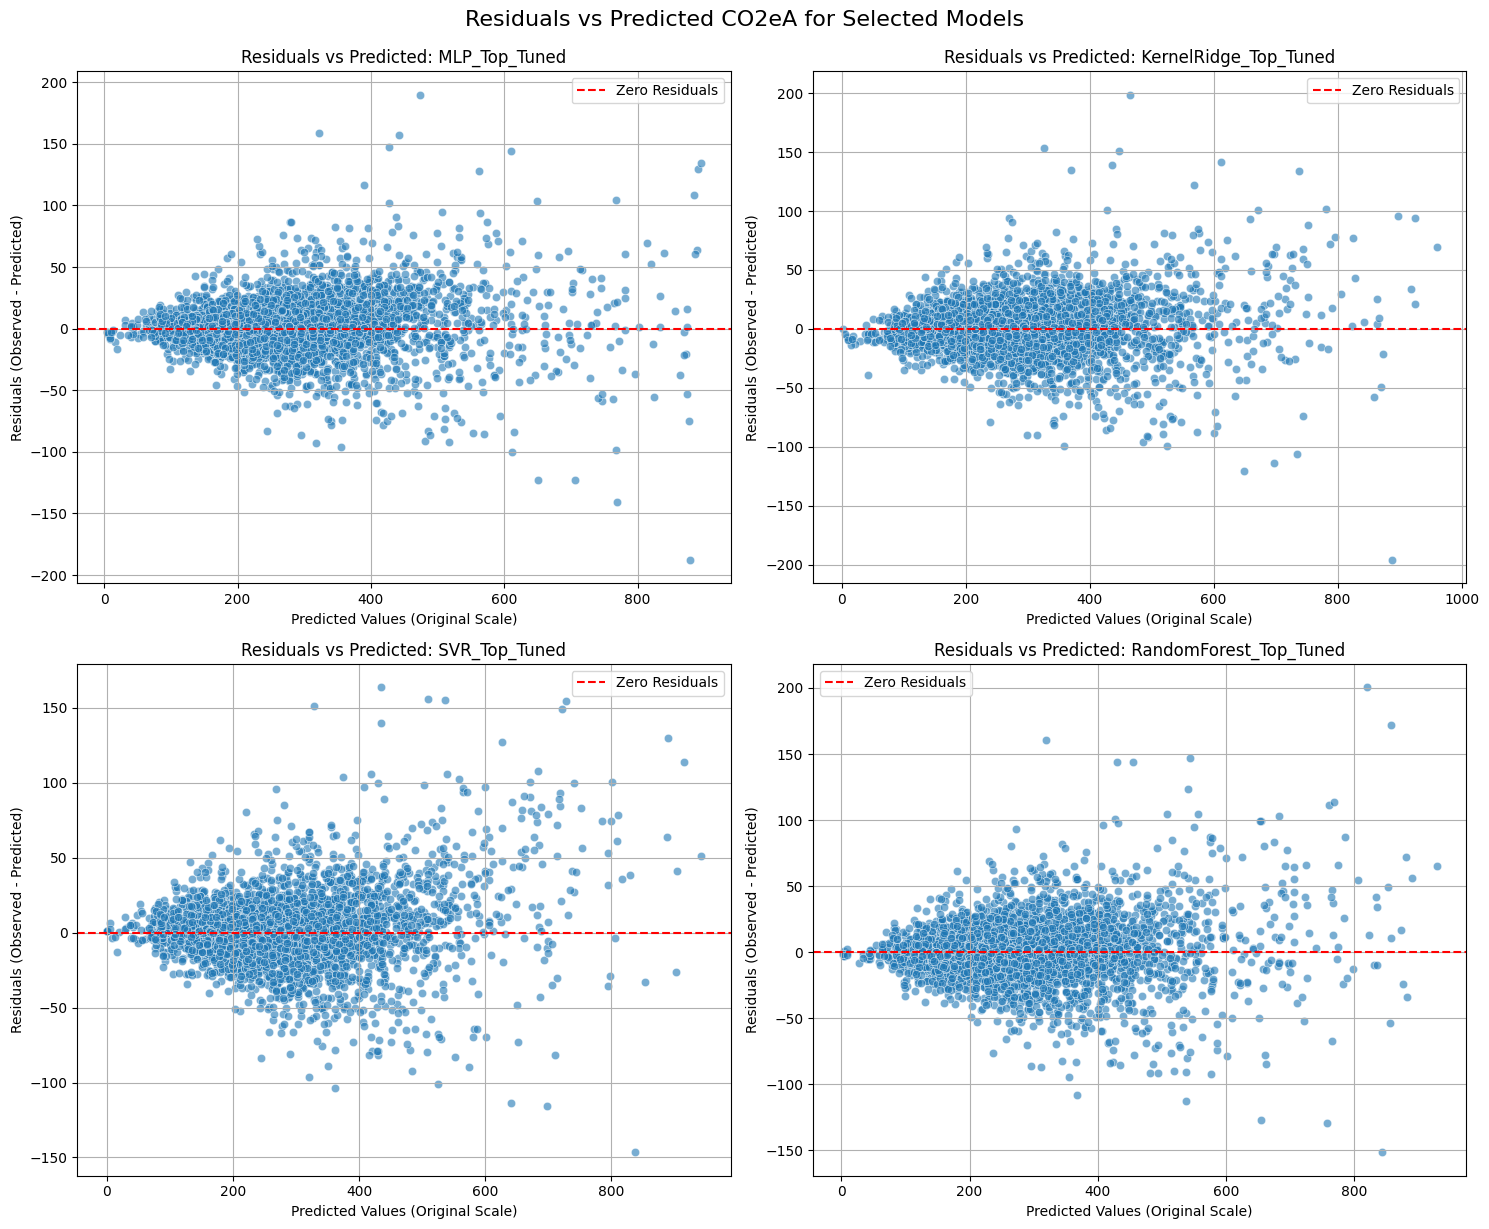

In [28]:
#@title Análisis de Residuos vs Predicciones
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

selected_models_for_plotting = [
    "MLP_Top_Tuned",
    "KernelRidge_Top_Tuned",
    "SVR_Top_Tuned",
    "RandomForest_Top_Tuned"
]

num_models = len(selected_models_for_plotting)
num_cols = 2 # Aim for 2 columns
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, model_name in enumerate(selected_models_for_plotting):
    ax = axes[i]

    # Plot Residuals vs Predicted
    sns.scatterplot(
        x=df_res[f'{model_name}_Predicted'],
        y=df_res[f'{model_name}_Residuals'],
        alpha=0.6,
        ax=ax
    )

    # Add a horizontal line at y=0 for reference
    ax.axhline(y=0, color='red', linestyle='--', label='Zero Residuals')

    ax.set_title(f'Residuals vs Predicted: {model_name}')
    ax.set_xlabel('Predicted Values (Original Scale)')
    ax.set_ylabel('Residuals (Observed - Predicted)')
    ax.legend()
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Residuals vs Predicted CO2eA for Selected Models', y=1.02, fontsize=16)
plt.show()

### Histograma de Residuos

El histograma de residuos permite evaluar la distribución de los errores del modelo. Idealmente, los residuos deben seguir una distribución normal con media cero, lo que sugiere que los errores del modelo son aleatorios y no tienen un sesgo sistemático.

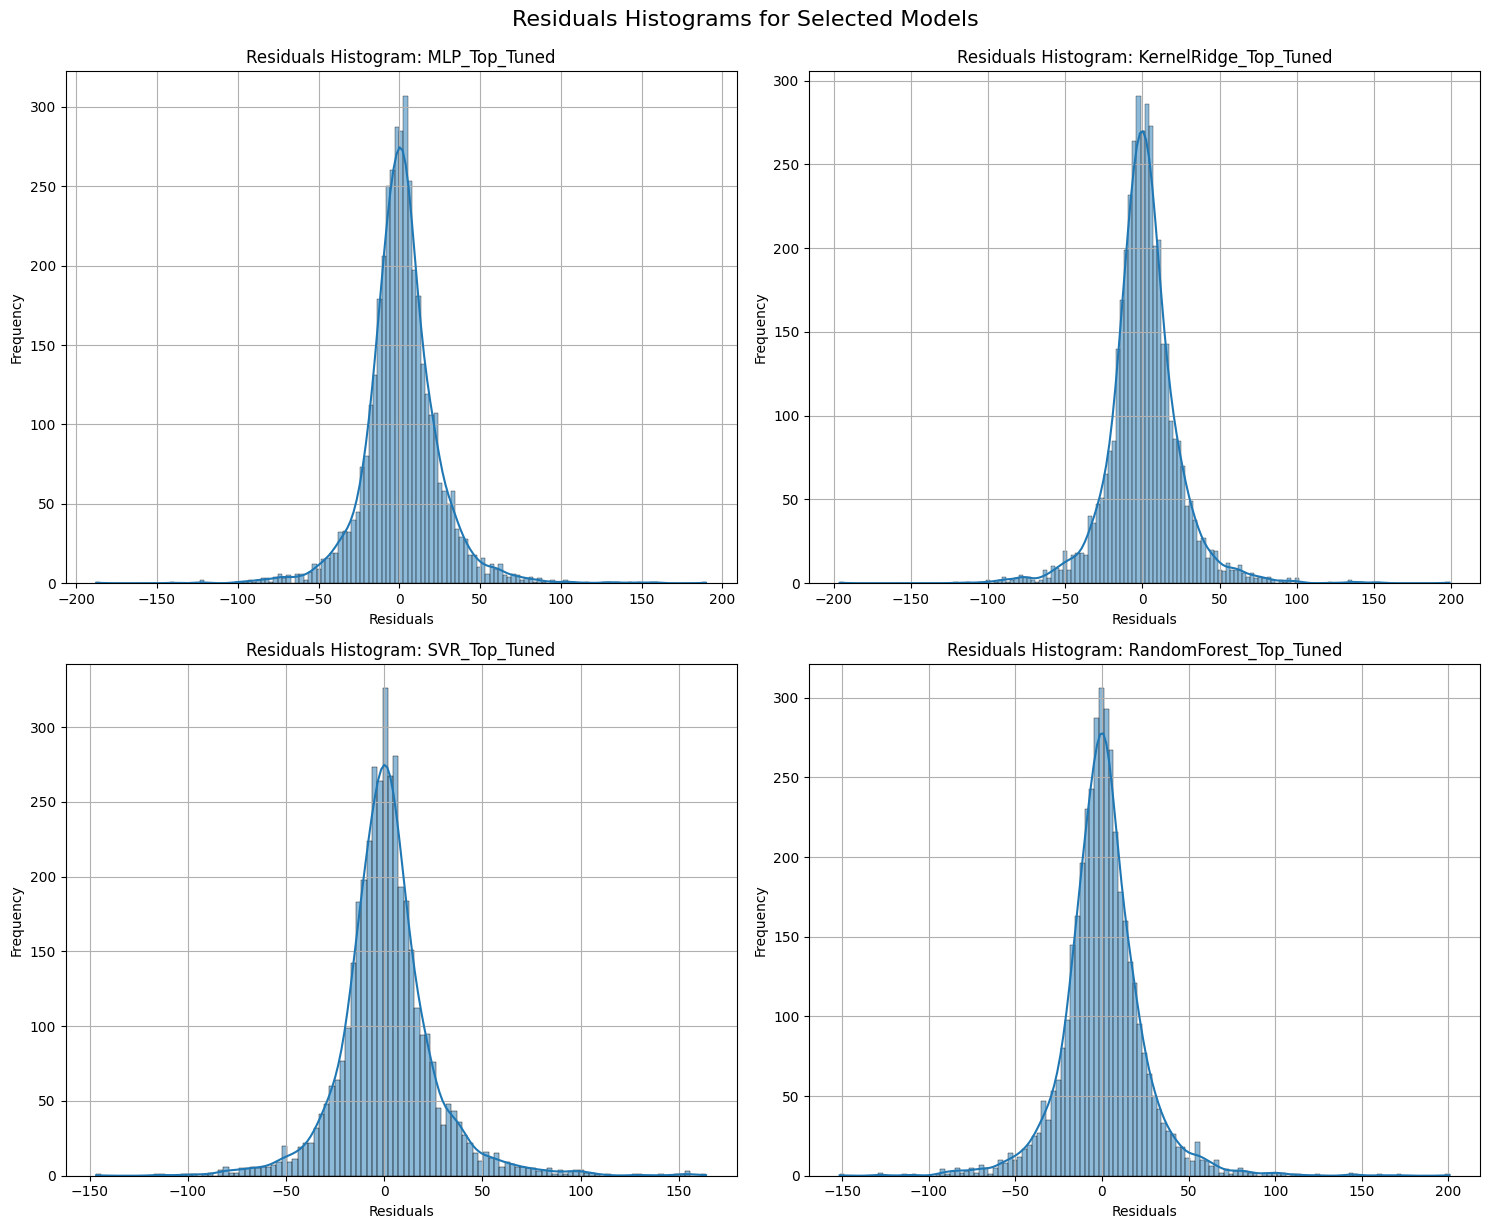

In [29]:
#@title Histograma de Residuos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

selected_models_for_plotting = [
    "MLP_Top_Tuned",
    "KernelRidge_Top_Tuned",
    "SVR_Top_Tuned",
    "RandomForest_Top_Tuned"
]

num_models = len(selected_models_for_plotting)
num_cols = 2 # Aim for 2 columns
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, model_name in enumerate(selected_models_for_plotting):
    ax = axes[i]

    # Plot Histogram of Residuals
    sns.histplot(
        df_res[f'{model_name}_Residuals'],
        kde=True, # Add Kernel Density Estimate
        ax=ax
    )

    ax.set_title(f'Residuals Histogram: {model_name}')
    ax.set_xlabel('Residuals')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Residuals Histograms for Selected Models', y=1.02, fontsize=16)
plt.show()

### SHAP Summary Plots

Los SHAP (SHapley Additive exPlanations) Summary Plots nos ayudan a entender la importancia de las características a nivel global y cómo cada característica influye en las predicciones del modelo. Un punto en el gráfico representa una instancia del conjunto de datos. La posición horizontal indica el impacto de esa característica en la predicción del modelo (valor SHAP), y el color indica el valor de la característica (rojo = alto, azul = bajo). Esto nos permite ver si valores altos o bajos de una característica impulsan la predicción hacia arriba o hacia abajo.

### Importancia de las Características (Feature Importance)

La importancia de las características nos permite entender qué variables de entrada son más relevantes para las predicciones de un modelo. A continuación, se muestra la importancia de las características para el modelo `RandomForest_Top_Tuned`, que es un modelo basado en árboles y, por lo tanto, puede proporcionar una medida directa de la importancia de cada característica.

Generating Feature Importance plot for RandomForest_Top_Tuned...


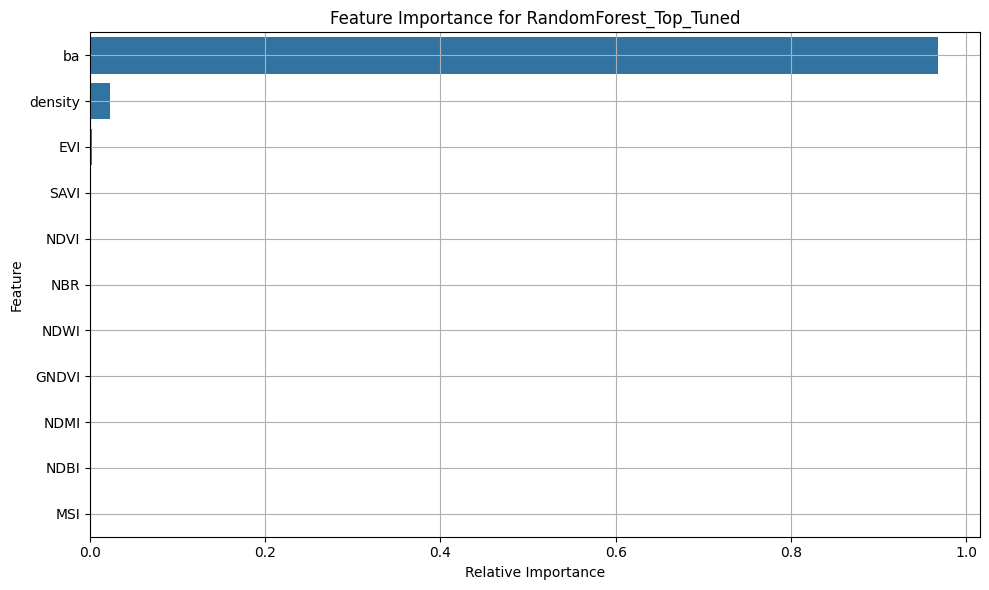

,Feature,Importance
9,ba,0.967629
10,density,0.023201
0,EVI,0.001557
8,SAVI,0.001519
6,NDVI,0.001280
3,NBR,0.001233
7,NDWI,0.000900
1,GNDVI,0.000882
5,NDMI,0.000713
4,NDBI,0.000547


Feature Importance plot generation complete.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating Feature Importance plot for RandomForest_Top_Tuned...")

# Get the pipeline for the RandomForest_Top_Tuned model
rf_pipeline = re_tuned_pipelines['RandomForest_Top_Tuned']

# Access the RandomForestRegressor model from the pipeline
rf_model = rf_pipeline.named_steps['model']

# Check if the model has feature_importances_ attribute
if hasattr(rf_model, 'feature_importances_'):
    feature_importances = rf_model.feature_importances_

    # Get feature names from the original X_train DataFrame
    feature_names = X_train.columns.tolist()

    # Create a DataFrame for visualization
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort by importance
    feature_df = feature_df.sort_values(by='Importance', ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df)
    plt.title('Feature Importance for RandomForest_Top_Tuned')
    plt.xlabel('Relative Importance')
    plt.ylabel('Feature')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    display(feature_df)
else:
    print("RandomForest_Top_Tuned model does not have 'feature_importances_'.")

print("Feature Importance plot generation complete.")

# **23. Conclusiones**
La evaluación inicial de 24 algoritmos de aprendizaje automático permitió identificar diferencias importantes en la capacidad predictiva de las distintas familias de modelos para estimar carbono equivalente aéreo (CO₂eA). Los mejores resultados se concentraron en modelos avanzados como Kernel Ridge, Support Vector Regression (SVR), Random Forest, redes neuronales artificiales (MLP) y algoritmos de boosting, mientras que los modelos de referencia (Dummy) mostraron desempeños considerablemente inferiores.
La estrategia de jerarquización basada en la suma de rankings permitió realizar una comparación integral considerando simultáneamente precisión, capacidad de generalización y eficiencia computacional. Este enfoque evitó depender de una única métrica y facilitó la identificación de modelos robustos y estables para las siguientes etapas del análisis.
La optimización de hiperparámetros mediante RandomizedSearchCV produjo mejoras consistentes en los modelos seleccionados, incrementando los valores de R² y reduciendo los errores de predicción en validación y prueba. Los resultados confirmaron que el ajuste adecuado de hiperparámetros constituye una etapa fundamental para maximizar el desempeño de los algoritmos de aprendizaje automático.
Los modelos KernelRidge_Top_Tuned, SVR_Top_Tuned, MLP_Top_Tuned y RandomForest_Top_Tuned destacaron como las alternativas más competitivas al presentar coeficientes de determinación superiores a 0.96 en validación y prueba, acompañados de bajos valores de RMSE y MAE. Asimismo, las diferencias reducidas entre los conjuntos de entrenamiento, validación y prueba evidenciaron una adecuada capacidad de generalización.
La validación cruzada de cinco particiones confirmó la estabilidad de los modelos optimizados, mostrando valores promedio elevados de R² y baja variabilidad entre particiones. Estos resultados indican que los modelos seleccionados mantienen un comportamiento consistente ante diferentes subconjuntos de datos y presentan un riesgo reducido de sobreajuste.
Las curvas de aprendizaje mostraron una convergencia favorable entre las métricas de entrenamiento y validación para la mayoría de los modelos optimizados, sugiriendo que la cantidad de información disponible es suficiente para obtener modelos estables y con buena capacidad predictiva. La ausencia de diferencias pronunciadas entre ambas curvas respalda la robustez de los modelos seleccionados.
La construcción y evaluación de modelos de ensamble permitió aprovechar las fortalezas complementarias de diferentes algoritmos. Los métodos de combinación, particularmente Stacking y Blending, demostraron el potencial de incrementar la precisión predictiva al integrar modelos con comportamientos distintos, cumpliendo el objetivo principal de la actividad relacionado con el aprendizaje por ensamble.
Los resultados obtenidos demuestran que las variables espectrales derivadas de sensores remotos (EVI, GNDVI, MSI, NBR, NDBI, NDMI, NDVI, NDWI y SAVI), complementadas con variables dasométricas como área basal y densidad, contienen información suficiente para explicar una alta proporción de la variabilidad observada en CO₂eA, alcanzando valores de R² cercanos a 0.97.
El proceso desarrollado permitió construir un marco metodológico reproducible para la comparación, optimización y selección de modelos predictivos, integrando evaluación tradicional, validación cruzada, análisis de generalización y técnicas de ensamble, lo que fortalece la confiabilidad de los resultados obtenidos.
El modelo final seleccionado proporciona una herramienta con alto potencial para apoyar la estimación de carbono forestal en bosques mezclados de Durango, contribuyendo al desarrollo de inventarios de carbono más precisos y al fortalecimiento de aplicaciones relacionadas con manejo forestal sustentable, monitoreo de existencias de carbono y proyectos de mitigación del cambio climático.
Los análisis de validación cruzada y curvas de aprendizaje proporcionaron evidencia adicional sobre la robustez de los modelos optimizados. El ranking basado en validación cruzada posicionó a KernelRidge_Top_Tuned como el modelo con mejor desempeño global (Global Rank = 1), seguido por Bagging_Top_Tuned, KNeighbors_Top_Tuned, RandomForest_Top_Tuned y MLP_Top_Tuned. En particular, Kernel Ridge alcanzó el mayor desempeño promedio en validación (R² = 0.9688), acompañado de los menores errores RMSE y MAE, confirmando una excelente capacidad de generalización. Asimismo, las curvas de aprendizaje mostraron una convergencia estable entre las métricas de entrenamiento y validación para Kernel Ridge, MLP y SVR, evidenciando un bajo riesgo de sobreajuste y una elevada estabilidad predictiva. Aunque Bagging y Random Forest presentaron valores de entrenamiento superiores, las diferencias observadas respecto a validación sugieren una ligera tendencia al sobreajuste, mientras que K-Neighbors mostró el comportamiento más sensible a la variabilidad de los datos. En conjunto, la evidencia obtenida mediante evaluación independiente, validación cruzada, análisis de generalización y curvas de aprendizaje respalda la selección de Kernel Ridge como la alternativa más equilibrada y robusta para la estimación de CO₂eA, al combinar altos niveles de precisión, estabilidad estadística y capacidad de generalización sobre datos no observados. Esta situación demuestra que las relaciones entre las variables espectrales, dasométricas y el carbono forestal presentan patrones complejos y no lineales que son capturados eficientemente por métodos kernel, constituyendo una herramienta confiable para aplicaciones de monitoreo de carbono, manejo forestal sustentable y desarrollo de proyectos de mitigación del cambio climático.